# Differential accessibility on pseudobulk with replicates

In [1]:
here::i_am("rna/mapping/run/mnn/mapping_mnn.R")

# Load default settings
source(here::here("settings.R"))
source(here::here("utils.R"))

# Load packages
suppressPackageStartupMessages(library(scran))
suppressPackageStartupMessages(library(scater))
suppressPackageStartupMessages(library(edgeR))
suppressPackageStartupMessages(library(org.Mm.eg.db))
suppressPackageStartupMessages(library(ggrastr))


here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/10_Eomes_invitro_gut/code



In [2]:
args = list()
args$sce = file.path(io$basedir, 'results/atac/archR/pseudobulk/celltype_genotype/PeakMatrix/PeakMatrix_pseudobulk_with_replicates.rds')
args$atac_matrix_file = file.path(io$basedir, 'processed/atac/archR/Matrices/PeakMatrix_summarized_experiment.rds')
args$groupA = 'WT'
args$groupB = 'Eomes_KO'
args$celltypes = opts$celltypes
args$outdir = file.path(io$basedir, 'results/atac/archR/differential')

args$archr_directory = file.path(io$basedir, 'processed/atac/archR')
args$metadata = file.path(io$basedir, 'results/atac/archR/qc/sample_metadata_after_qc.txt.gz')

In [3]:

dir.create(args$outdir, showWarnings = F)

# Define groups
opts$groups <- c(args$groupA,args$groupB)

opts$min_cdr <- 0.15

In [5]:
atac.mtx = readRDS(args$atac_matrix_file)

In [6]:
assayNames(atac.mtx)[1] <- "counts"

In [7]:
###############
## Load data ##
###############

print(sprintf("Fetching ATAC matrix: '%s'...",args$atac_matrix_file))

atac.se <- readRDS(args$sce)
assayNames(atac.se)[1] <- "counts"

# Normalise with log2 counts (for consistentcy with edgeR)
logcounts(atac.se) <- log2(1e6*(sweep(counts(atac.se),2,colSums(counts(atac.se)),"/"))+1)

# parse
if (!"celltype" %in% colnames(colData(atac.se))) {
  atac.se$celltype <- colnames(atac.se) %>% strsplit("-") %>% map_chr(1)
}
if (!"genotype" %in% colnames(colData(atac.se))) {
  atac.se$genotype <- colnames(atac.se) %>% strsplit("-") %>% map_chr(2) %>% strsplit("_rep") %>% map_chr(1)
}
if (!"celltype_genotype" %in% colnames(colData(atac.se))) {
  atac.se$celltype_genotype <- sprintf("%s_%s",atac.se$celltype,atac.se$genotype)
}

# temporary (otherwise subsetting doesn't work???)
if ("start" %in% colnames(rowData(atac.se))) {
  rowData(atac.se)$start <- NULL
}
if ("end" %in% colnames(rowData(atac.se))) {
  rowData(atac.se)$end <- NULL
}

[1] "Fetching ATAC matrix: '/rds/project/rds-SDzz0CATGms/users/bt392/10_Eomes_invitro_gut/processed/atac/archR/Matrices/PeakMatrix_summarized_experiment.rds'..."


In [8]:
atac.se_full = atac.se

In [37]:
gg_volcano_plot <- function(celltype_i='Allantois', top_genes=10, xlim=5, ylim=40, label_groups = NULL) {
  to.plot = DARs[celltype == celltype_i]
  negative_hits <- to.plot[sig==TRUE & logFC<0,feature]
  positive_hits <- to.plot[sig==TRUE & logFC>0,feature]
  all <- nrow(to.plot[!is.na(sig)])
  to.plot = to.plot[,logFC_plot:=ifelse(logFC<=-xlim, -xlim, ifelse(logFC>=xlim, xlim, logFC))] %>% 
                  .[,log10_padj_fdr:=ifelse(-log10(padj_fdr)>=ylim, ylim, -log10(padj_fdr))]
  
  # if (is.null(xlim))
  #   xlim <- max(abs(to.plot$logFC), na.rm=T)
  # if (is.null(ylim))
  #   ylim <- max(-log10(to.plot$padj_fdr+1e-100), na.rm=T)
  
  to.plot <- to.plot[!is.na(logFC) & !is.na(padj_fdr)] %>% .[order(-abs(logFC))]
  label_genes = c(head(to.plot[sig==T & logFC<=0, feature],n=top_genes), head(to.plot[sig==T & logFC>=0, feature],n=top_genes))
  
  p <- ggplot(to.plot, aes(x=logFC_plot, y=log10_padj_fdr)) +
    labs(x="Log fold change", y=expression(paste("-log"[10],"(q.value)"))) +
    ggrastr::geom_point_rast(aes(color=sig, size=sig)) +
    # geom_hline(yintercept = -log10(opts$threshold_fdr), color="blue") +
    geom_segment(aes(x=0, xend=0, y=0, yend=ylim*0.9), color="orange", size=0.5) +
    scale_color_manual(values=c("black","red")) +
    scale_size_manual(values=c(0.5,1)) +
    scale_x_continuous(limits=c(-xlim,xlim)) +
    scale_y_continuous(limits=c(0,ylim)) +
    annotate("text", x=0, y=ylim*0.95, size=6, label=sprintf("(%d)", all)) +
    annotate("text", x=-xlim*0.8, y=ylim*0.95, size=6, label=sprintf("%d (-)",length(negative_hits))) +
    annotate("text", x=xlim*0.8, y=ylim*0.95, size=6, label=sprintf("%d (+)",length(positive_hits))) +
    ggrepel::geom_text_repel(data=to.plot[feature %in% label_genes],
                                    aes(x=logFC_plot, y=log10_padj_fdr, label=feature), max.overlaps=Inf, size=5) +
    theme_classic() +
    theme(
       axis.text = element_text(color='black'),
      # axis.title = element_text(size=rel(1.0), color='black'),
      text=element_text(size=15),
      legend.position="none"
    ) + 
    ggtitle(celltype_i)
  
  
  if (length(label_groups)>0) {
    p <- p +
      annotate("text", x=-4, y=0, size=4, label=sprintf("Up in %s",label_groups[2])) +
      annotate("text", x=4, y=0, size=4, label=sprintf("Up in %s",label_groups[1]))
  }
  
  return(rasterize(p, dpi=600))
}

# Ricard's method:

In [155]:
DARs = lapply(args$celltypes, function(ct){
    print(ct)
    tmp <- sprintf("%s_%s",ct,opts$groups)
    if (any(!tmp%in%unique(atac.se_full$celltype_genotype))) {
      warning("...")
      out <- data.table(feature=NA, logFC=NA, padj_fdr=NA, mean_groupA=NA, mean_groupB=NA)
      #fwrite(out, args$outfile, sep="\t", na="NA", quote=F)
    } else {
      atac.se <- atac.se_full[,atac.se_full$celltype %in% ct]
    

        # # subset genotypes
        stopifnot(opts$groups%in%atac.se$genotype)
        atac.se$genotype <- factor(atac.se$genotype, levels=opts$groups)
        print(table(atac.se$celltype_genotype))

        ##################################
        ## calculate feature statistics ##
        ##################################
        # using original single-cell data to determine detection rate

        atac.mtx_tmp <- atac.mtx[,atac.mtx$celltype %in% ct]
        stopifnot(opts$groups%in%atac.mtx_tmp$genotype)
        atac.mtx_tmp$genotype <- factor(atac.mtx_tmp$genotype, levels=opts$groups)
        print(table(atac.mtx_tmp$celltype_genotype))
        
        acc.dt <- data.table(
          feature = rownames(atac.mtx_tmp),
          detection_rate_groupA = rowMeans(assay(atac.mtx_tmp,"counts")[,colData(atac.mtx_tmp)$genotype==opts$groups[1]]>0) %>% round(2),
          detection_rate_groupB = rowMeans(assay(atac.mtx_tmp,"counts")[,colData(atac.mtx_tmp)$genotype==opts$groups[2]]>0) %>% round(2),
          mean_groupA = rowMeans(logcounts(atac.se[,atac.se$genotype==args$groupA])) %>% round(2),
          mean_groupB = rowMeans(logcounts(atac.se[,atac.se$genotype==args$groupB])) %>% round(2)
        )

        #####################################
        ## Differential testing with edgeR ##
        #####################################

        # Consider only features that have a minimum detection rate
        features.to.use <- acc.dt[detection_rate_groupA>=opts$min_cdr | detection_rate_groupB>=opts$min_cdr,feature]

        # Create DGEList
        atac.dge <- DGEList(assay(atac.se[features.to.use,],"counts"))

        # Define design matrix (with intercept)
        design <- model.matrix(~atac.se$genotype)

        # Estimate dispersions
        atac.dge <- estimateDisp(atac.dge,design)

        # Fit GLM
        fit <- glmQLFit(atac.dge,design)

        # Likelihood ratio test
        lrt <- glmQLFTest(fit)

        # Construct output data.frame
        out <- topTags(lrt, n=nrow(lrt))$table %>% as.data.table(keep.rownames=T) %>%
            setnames(c("feature","logFC","logCPM","LR","p.value","padj_fdr")) %>%
            .[,c("logCPM","LR","p.value"):=NULL] %>%
          merge(acc.dt[,c("feature","mean_groupA","mean_groupB")], by="feature", all.y=TRUE) %>%
            .[,c("padj_fdr","logFC"):=list(signif(padj_fdr,digits=3),round(logFC,3))] %>%
            .[is.na(logFC),c("logFC","padj_fdr"):=list(0,1)] %>%
            setorder(padj_fdr, na.last=T)

    }
    out = out %>% .[,celltype:=ct]
    return(out)
})

[1] "Epiblast"

Epiblast_Eomes_KO       Epiblast_WT 
                5                 5 

Epiblast-Eomes_KO       Epiblast-WT 
             2242              8096 
[1] "Primitive_Streak"

Primitive_Streak_Eomes_KO       Primitive_Streak_WT 
                        5                         5 

Primitive_Streak-Eomes_KO       Primitive_Streak-WT 
                    13695                      7244 
[1] "Caudal_epiblast"

Caudal_epiblast_Eomes_KO       Caudal_epiblast_WT 
                       5                        5 

Caudal_epiblast-Eomes_KO       Caudal_epiblast-WT 
                     151                       95 
[1] "PGC"

PGC_Eomes_KO       PGC_WT 
           5            5 

PGC-Eomes_KO       PGC-WT 
         319          548 
[1] "Anterior_Primitive_Streak"

Anterior_Primitive_Streak_Eomes_KO       Anterior_Primitive_Streak_WT 
                                 5                                  5 

Anterior_Primitive_Streak-Eomes_KO       Anterior_Primitive_Streak-WT 
   

Warning message in FUN(X[[i]], ...):
“...”


[1] "Def._endoderm"


Warning message in FUN(X[[i]], ...):
“...”


[1] "Gut"


...

Warning message in FUN(X[[i]], ...):
“...”


[1] "ExE_ectoderm"


Warning message in FUN(X[[i]], ...):
“...”


[1] "Parietal_endoderm"


Warning message in FUN(X[[i]], ...):
“...”


In [156]:
DARs = rbindlist(DARs) %>% 
    .[,sig:=ifelse(abs(logFC)>0.5 & padj_fdr<0.05, TRUE, FALSE)] %>%
    .[,direction:=ifelse(logFC>0, 'up', 'down')] 

In [157]:
fwrite(DARs, file.path(args$outdir, 'DARs_ricard.txt.gz'))

In [12]:
table(DARs$sig, DARs$direction)

       
          down     up
  FALSE 757892 124428
  TRUE   24071  20101

In [13]:
DAR_stats = DARs[sig==TRUE] %>% 
    .[,N:=.N, by=c('celltype','direction')] %>%  unique(by=c('celltype','direction')) %>%
    .[,celltype:=factor(celltype, levels=opts$celltypes)]

In [14]:
options(repr.plot.width=20, repr.plot.height=5) 

options(repr.plot.width = 15,repr.plot.height = 5)
p = ggplot(DAR_stats, aes(celltype, N, fill=direction)) +
    geom_bar(stat='identity', position='dodge') +
    scale_fill_manual(values=c('up'='burlywood', 'down'='cadetblue')) + 
    ylab('Number of peaks') + 
    theme_bw() + 
    theme(text=element_text(size=15),
          axis.text=element_text(color='black'),
          axis.text.x=element_text(angle=-25, hjust=0, vjust=1),
          axis.title.x=element_blank())

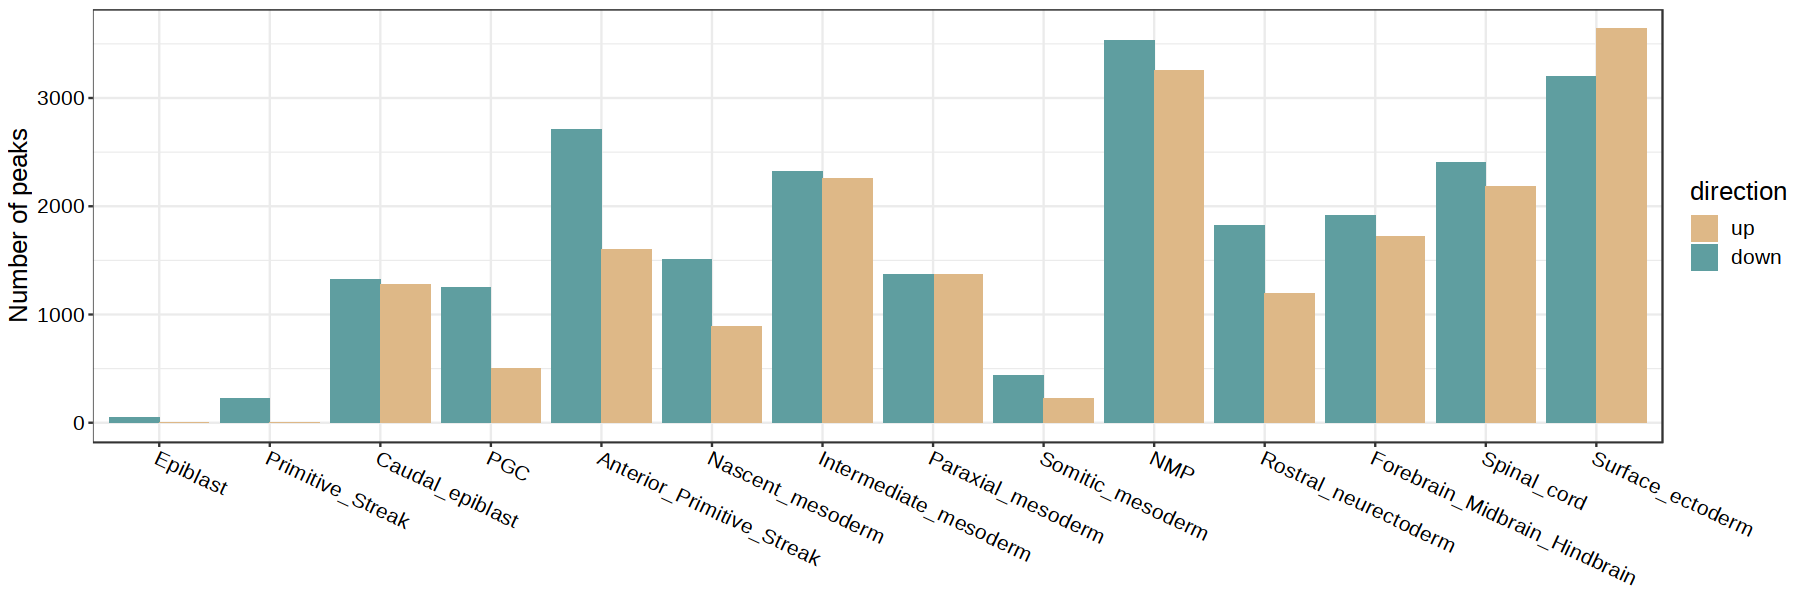

In [15]:
p

In [16]:
celltypes_keep = unique(DARs[!is.na(feature),celltype])

In [38]:
DEG_plots = lapply(celltypes_keep, gg_volcano_plot, top_genes=0)
names(DEG_plots) = celltypes_keep

DEG_plots_filt = list()

for(i in celltypes_keep){
DEG_plots_filt[[i]] = DEG_plots[[i]]
}

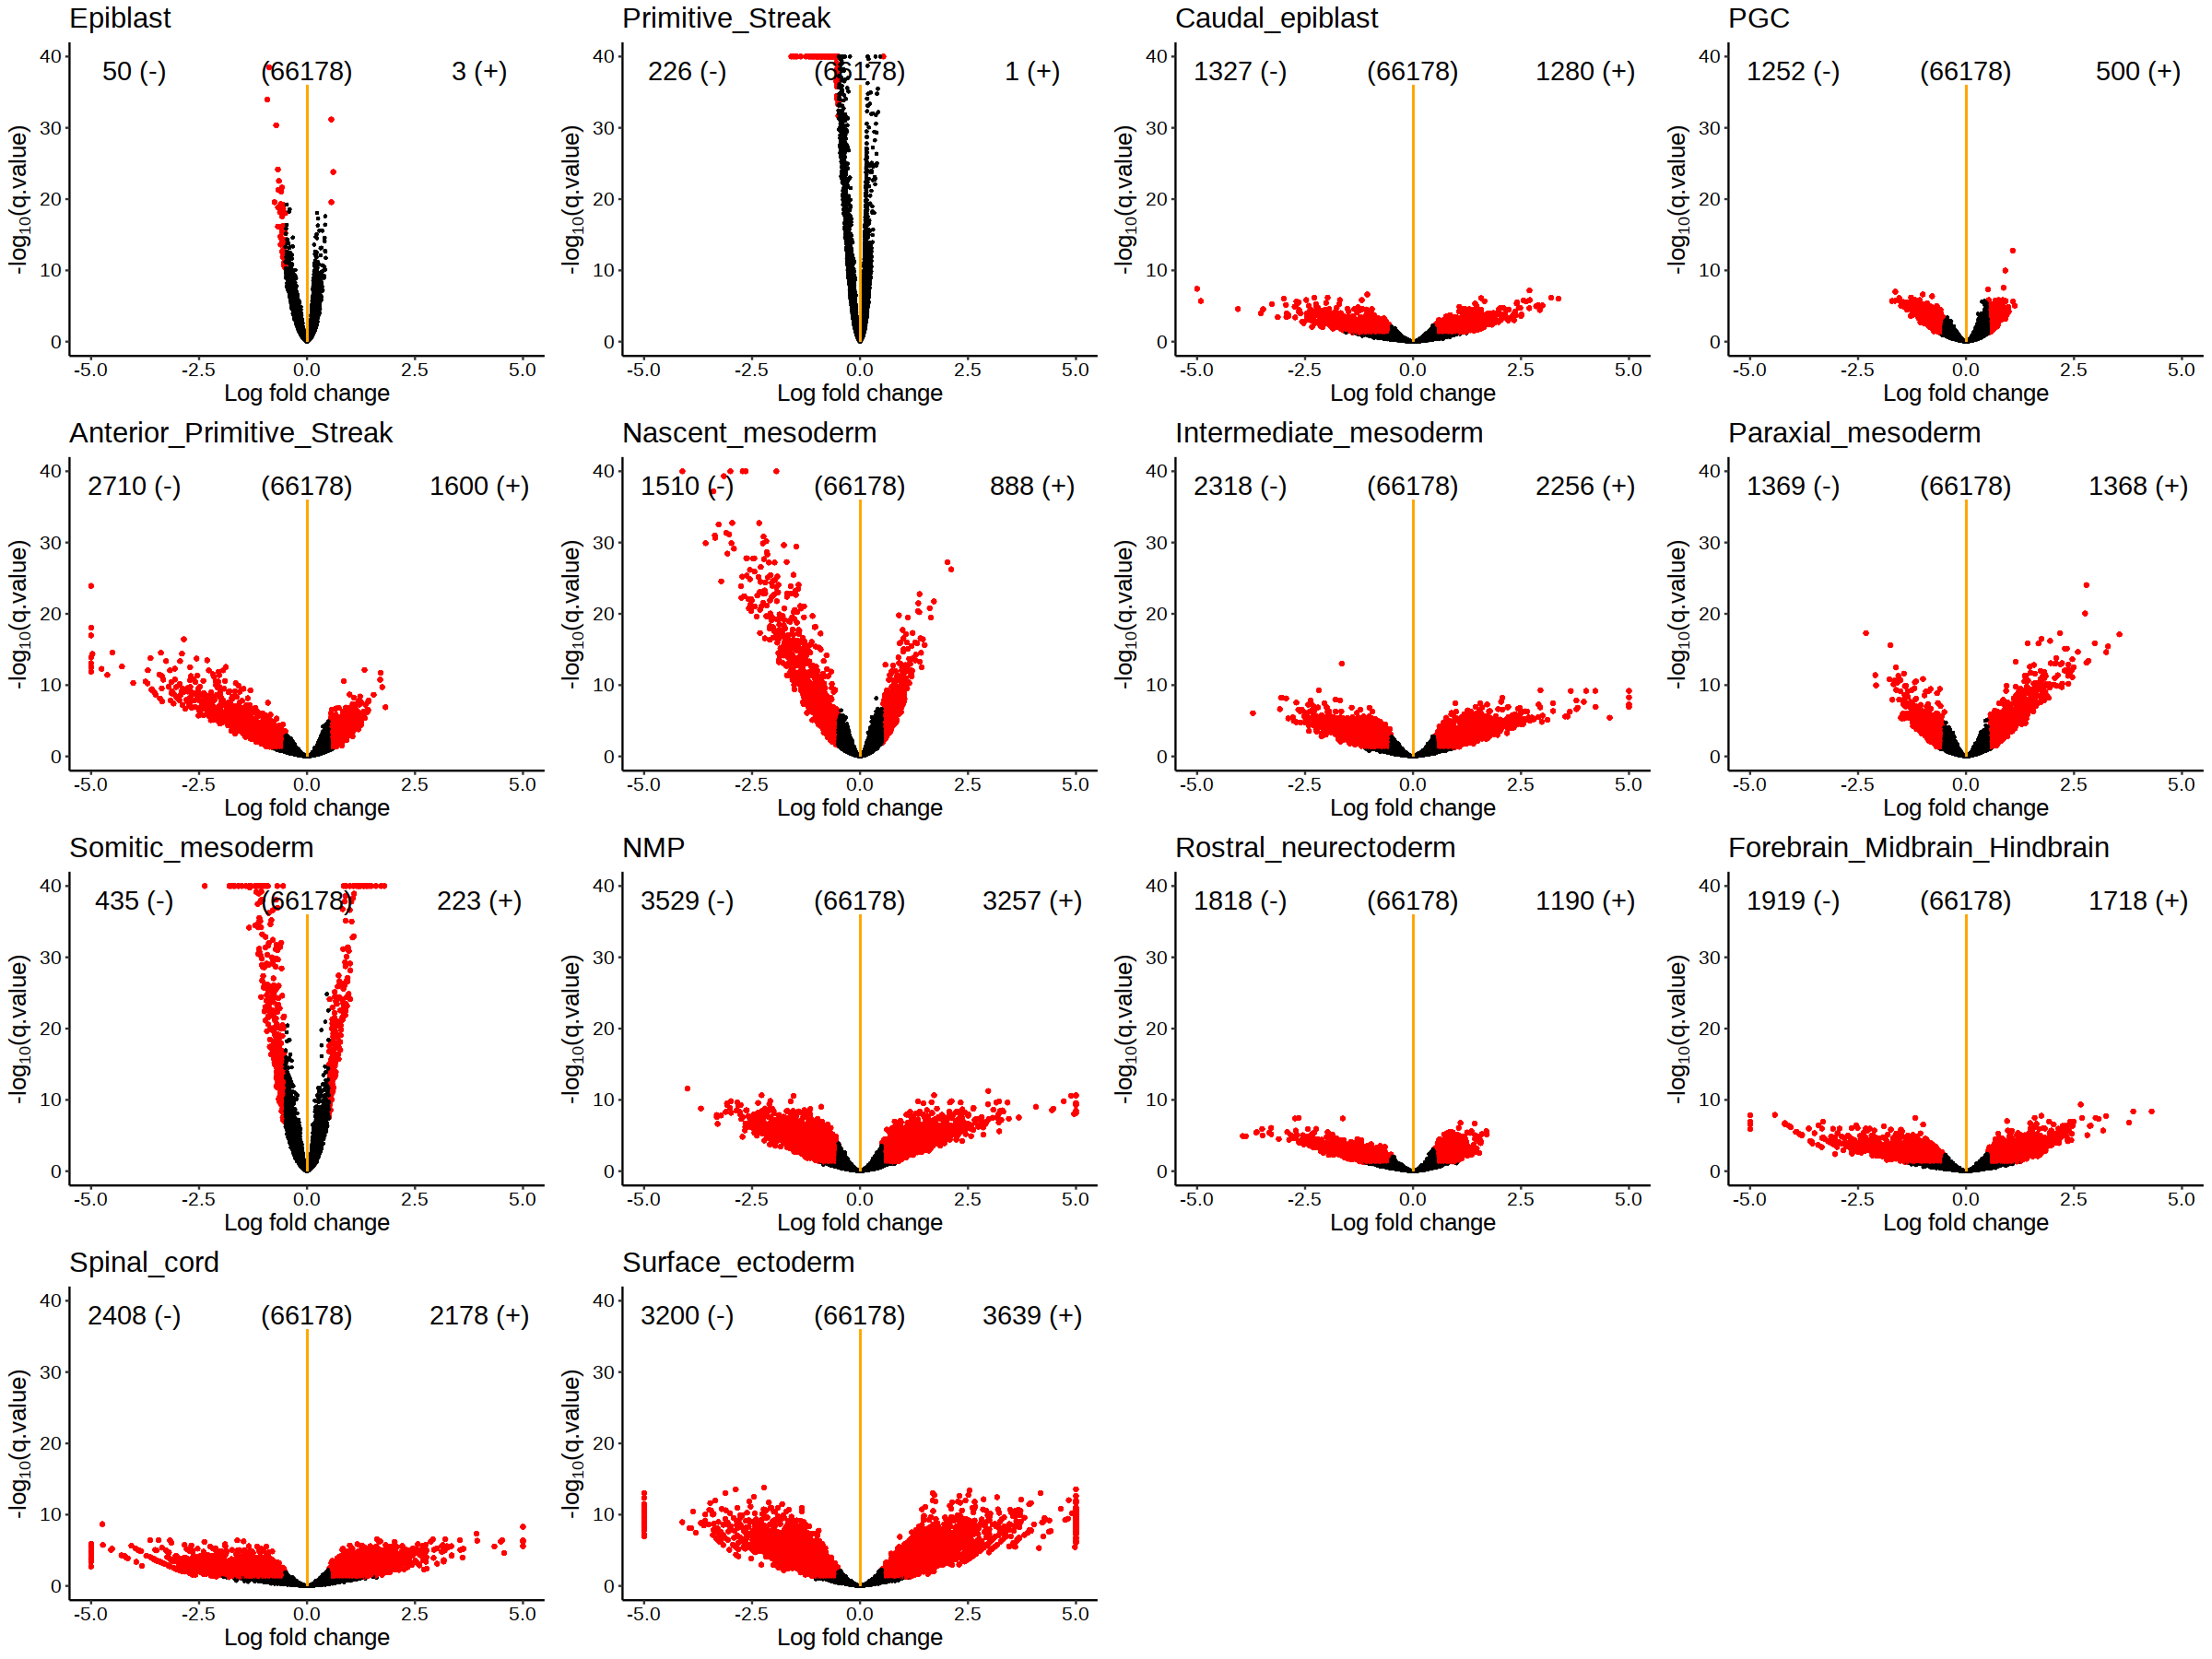

In [39]:
options(repr.plot.width=20, repr.plot.height=15) 
ggarrange(plotlist=DEG_plots_filt)

# ArchR

In [4]:
suppressPackageStartupMessages(library(ArchR))
setwd(args$archr_directory)

addArchRVerbose(verbose = FALSE)
addArchRGenome("mm10")

Setting addArchRVerbose = FALSE

Setting default genome to Mm10.



In [5]:
########################
## Load cell metadata ##
########################

cell_metadata.dt <- fread(args$metadata) %>%
  .[pass_atacQC==TRUE & doublet_call==FALSE]

## Load ArchRProject
# Subset
ArchRProject <- loadArchRProject(args$archr_directory)[cell_metadata.dt$cell]

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
           ___      .______        ______  __    __  .____

In [6]:
meta = as.data.table(ArchRProject@cellColData)

features = rownames(atac.mtx)

ERROR: Error in h(simpleError(msg, call)): error in evaluating the argument 'x' in selecting a method for function 'rownames': object 'atac.mtx' not found


In [43]:
keep = rownames(ArchRProject@cellColData)

In [44]:
atac.mtx = atac.mtx[,keep]

In [7]:
table(ArchRProject@cellColData$celltype, ArchRProject@cellColData$genotype)

                                
                                 Eomes_KO    WT
  Anterior_Primitive_Streak           151  1892
  Blood_progenitors_1                   0     1
  Caudal_epiblast                     151    95
  Caudal_Mesoderm                      88    20
  Caudal_neurectoderm                   3     3
  Def._endoderm                        16  1335
  Endothelium                           2     0
  Epiblast                           2242  8096
  ExE_ectoderm                          1     0
  Forebrain_Midbrain_Hindbrain         72   186
  Gut                                   0   116
  Haematoendothelial_progenitors       13     2
  Intermediate_mesoderm               259    54
  Mixed_mesoderm                       28     7
  Nascent_mesoderm                    510   710
  Neural_crest                          3     0
  NMP                                 294    37
  Notochord                             0   300
  Paraxial_mesoderm                  1359   170
  Parie

In [48]:
DARs = lapply(unique(ArchRProject@cellColData$celltype), function(ct, min_cells=25){ #args$celltypes
    tmp <- sprintf("%s_%s",ct,opts$groups)
    if (nrow(meta[celltype_genotype == paste0(ct, '-Eomes_KO')]) < min_cells | nrow(meta[celltype_genotype == paste0(ct, '-WT')]) < min_cells) {
      out <- data.table(Log2FC=NA, Mean=NA, FDR=NA, Pval=NA, MeanDiff=NA, MeanBGD=NA, idx=NA, feature=NA)
      message('skipping ', ct, ' due to low cell number')
    } else {
        
        #stopifnot(opts$groups%in%atac.se$genotype)
        #atac.se$genotype <- factor(atac.se$genotype, levels=opts$groups)
        
        ##################################
        ## calculate feature statistics ##
        ##################################
        # using original single-cell data to determine detection rate

        atac.mtx_tmp <- atac.mtx[,atac.mtx$celltype %in% ct]
        stopifnot(opts$groups%in%atac.mtx_tmp$genotype)
        atac.mtx_tmp$genotype <- factor(atac.mtx_tmp$genotype, levels=opts$groups)
        
        acc.dt <- data.table(
          feature = rownames(atac.mtx_tmp),
          detection_rate_groupA = rowMeans(assay(atac.mtx_tmp,"counts")[,colData(atac.mtx_tmp)$genotype==opts$groups[1]]>0) %>% round(2),
          detection_rate_groupB = rowMeans(assay(atac.mtx_tmp,"counts")[,colData(atac.mtx_tmp)$genotype==opts$groups[2]]>0) %>% round(2)
        )
        
        # Consider only features that have a minimum detection rate
        features.to.use <- acc.dt[detection_rate_groupA>=opts$min_cdr | detection_rate_groupB>=opts$min_cdr,feature]
        message(ct, ' with ', length(features.to.use), ' regions')

        #ArchRProject.filt = ArchRProject[ArchRProject@cellColData$celltype==ct,]
        ##########################
        ## Differential testing ##
        ##########################
        
        # sometimes get errors, because of NA's in matrix? but ArchR doesn't allow me to subset the peakmatrix
        out <- suppressMessages(getMarkerFeatures( # suppressMessages(
          ArchRProj = ArchRProject, #.filt, 
          useMatrix = "PeakMatrix",
          groupBy = "celltype_genotype",
          testMethod = "binomial",
          binarize=TRUE,
          useGroups = paste0(ct, '-Eomes_KO'),
          bgdGroups = paste0(ct, '-WT'),
          bias = c("TSSEnrichment", "log10(nFrags)"),
          verbose=TRUE
        ))
        
        # ArchR doesn't allow to select only specified features for differential testing, so instead I run it on everything 
        # Here I select only the relevant features and redo fdr correction.
        out = as.data.table(do.call("cbind", out@assays@data)) %>% 
            setnames(names(out@assays@data)) %>%
            .[,idx:=1:nrow(.)] %>%
            .[,feature := features] %>% 
            .[feature %in% features.to.use,] %>%
            .[,FDR := p.adjust(Pval, method = 'fdr')]
        
        
    }
    out = out %>% .[,celltype:=ct]
    return(out)
}) %>%  rbindlist(.) %>% 
    setnames(c('Log2FC', 'FDR'), c('logFC', 'padj_fdr'))

Epiblast with 24053 regions

Rostral_neurectoderm with 18609 regions

Primitive_Streak with 25858 regions

PGC with 21738 regions

skipping Def._endoderm due to low cell number

Forebrain_Midbrain_Hindbrain with 18196 regions

NMP with 20948 regions

Nascent_mesoderm with 23969 regions

skipping Parietal_endoderm due to low cell number

Caudal_epiblast with 18761 regions

Anterior_Primitive_Streak with 28092 regions

Surface_ectoderm with 15835 regions

skipping ExE_ectoderm due to low cell number

skipping Visceral_endoderm due to low cell number

Somitic_mesoderm with 22085 regions

Paraxial_mesoderm with 21494 regions

skipping Caudal_neurectoderm due to low cell number

Intermediate_mesoderm with 18625 regions

skipping Caudal_Mesoderm due to low cell number

Spinal_cord with 21115 regions

skipping Mixed_mesoderm due to low cell number

skipping Pharyngeal_mesoderm due to low cell number

skipping Haematoendothelial_progenitors due to low cell number

skipping Neural_crest due to 

In [49]:
fwrite(DARs, file.path(args$outdir, 'DARs.txt.gz'))

In [26]:
DARs = fread(file.path(args$outdir, 'DARs.txt.gz'))

In [17]:
DARs = DARs %>% 
    .[,sig:=ifelse(abs(logFC)>0.5 & padj_fdr<0.05, TRUE, FALSE)] %>%
    .[,direction:=ifelse(logFC>0, 'up', 'down')] 

In [18]:
table(DARs[sig==TRUE]$celltype, DARs[sig==TRUE]$direction)

                              
                               down   up
  Anterior_Primitive_Streak    2710 1600
  Caudal_epiblast              1327 1280
  Epiblast                       50    3
  Forebrain_Midbrain_Hindbrain 1919 1718
  Intermediate_mesoderm        2318 2256
  Nascent_mesoderm             1510  888
  NMP                          3529 3257
  Paraxial_mesoderm            1369 1368
  PGC                          1252  500
  Primitive_Streak              226    1
  Rostral_neurectoderm         1818 1190
  Somitic_mesoderm              435  223
  Spinal_cord                  2408 2178
  Surface_ectoderm             3200 3639

In [59]:
ct_keep = c('Epiblast', 'Primitive_Streak', 'PGC', 'Anterior_Primitive_Streak', 'Nascent_mesoderm', 'Intermediate_mesoderm', 'Somitic_mesoderm', 'Rostral_neurectoderm', 'Forebrain_Midbrain_Hindbrain', 'Surface_ectoderm')

In [60]:
unique(DAR_stats$celltype)

[1] Epiblast                     Rostral_neurectoderm        
 [3] Primitive_Streak             PGC                         
 [5] Forebrain_Midbrain_Hindbrain NMP                         
 [7] Nascent_mesoderm             Caudal_epiblast             
 [9] Anterior_Primitive_Streak    Surface_ectoderm            
[11] Somitic_mesoderm             Paraxial_mesoderm           
[13] Intermediate_mesoderm        Spinal_cord                 
37 Levels: Epiblast Primitive_Streak Caudal_epiblast ... Parietal_endoderm

In [64]:
DAR_stats = DARs[sig==TRUE] %>% 
    .[celltype %in% ct_keep] %>% 
    .[,N:=.N, by=c('celltype','direction')] %>%  unique(by=c('celltype','direction')) %>%
    .[,celltype:=factor(celltype, levels=ct_keep)]

In [65]:
options(repr.plot.width=20, repr.plot.height=5) 

options(repr.plot.width = 15,repr.plot.height = 5)
p = ggplot(DAR_stats, aes(celltype, N, fill=direction)) +
    geom_bar(stat='identity', position='dodge') +
    scale_fill_manual(values=c('up'='burlywood', 'down'='cadetblue')) + 
    ylab('Number of peaks') + 
    theme_bw() + 
    theme(text=element_text(size=15),
          axis.text=element_text(color='black'),
          axis.text.x=element_text(angle=-25, hjust=0, vjust=1),
          axis.title.x=element_blank())

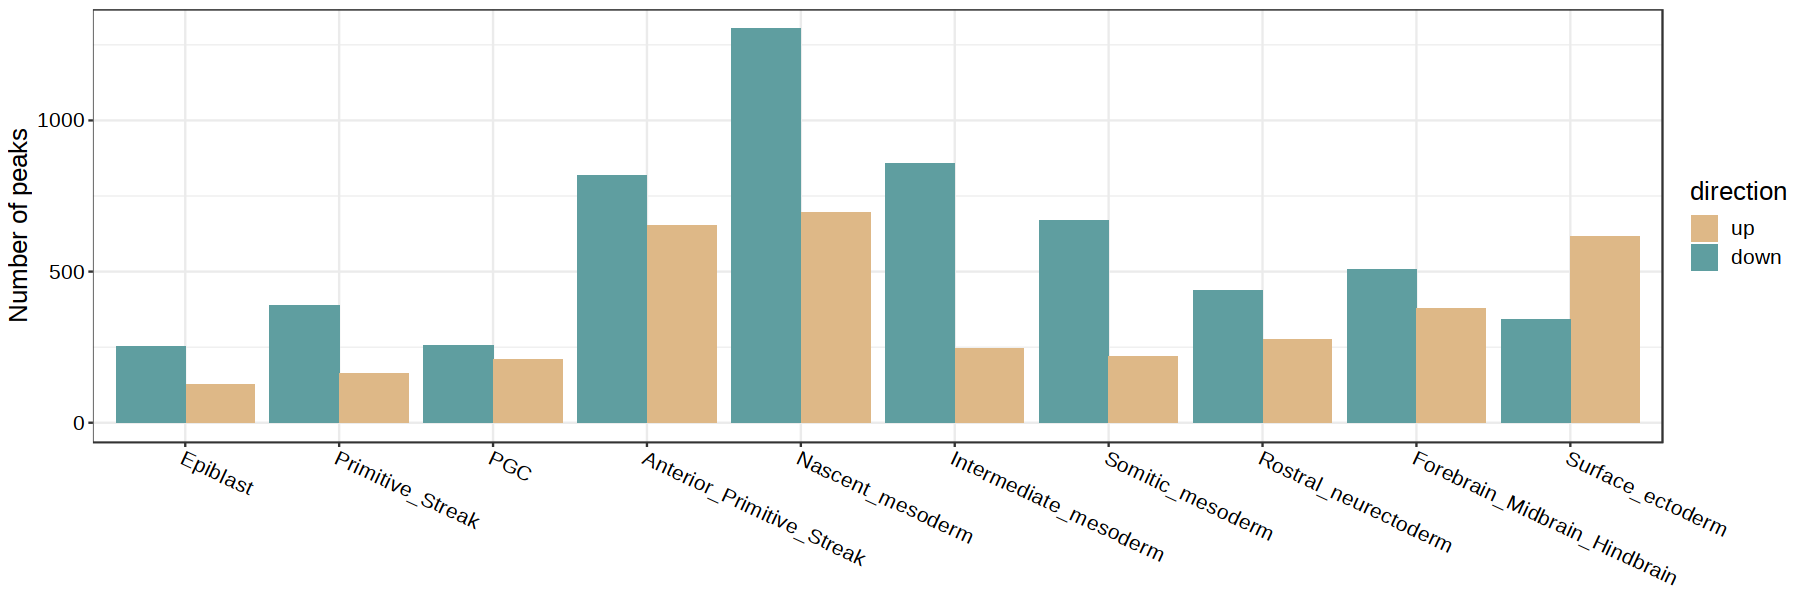

In [66]:
p

In [67]:
pdf(sprintf('%s/DAR_stats.pdf', args$outdir), width=8, height=4)
     print(p)
dev.off()

png 
  2

In [68]:
celltypes_keep = unique(DARs[!is.na(feature),celltype])

In [72]:
DEG_plots = lapply(celltypes_keep, gg_volcano_plot, top_genes=0, xlim=3, ylim=20)
names(DEG_plots) = celltypes_keep

DEG_plots_filt = list()

for(i in celltypes_keep){
DEG_plots_filt[[i]] = DEG_plots[[i]]
}

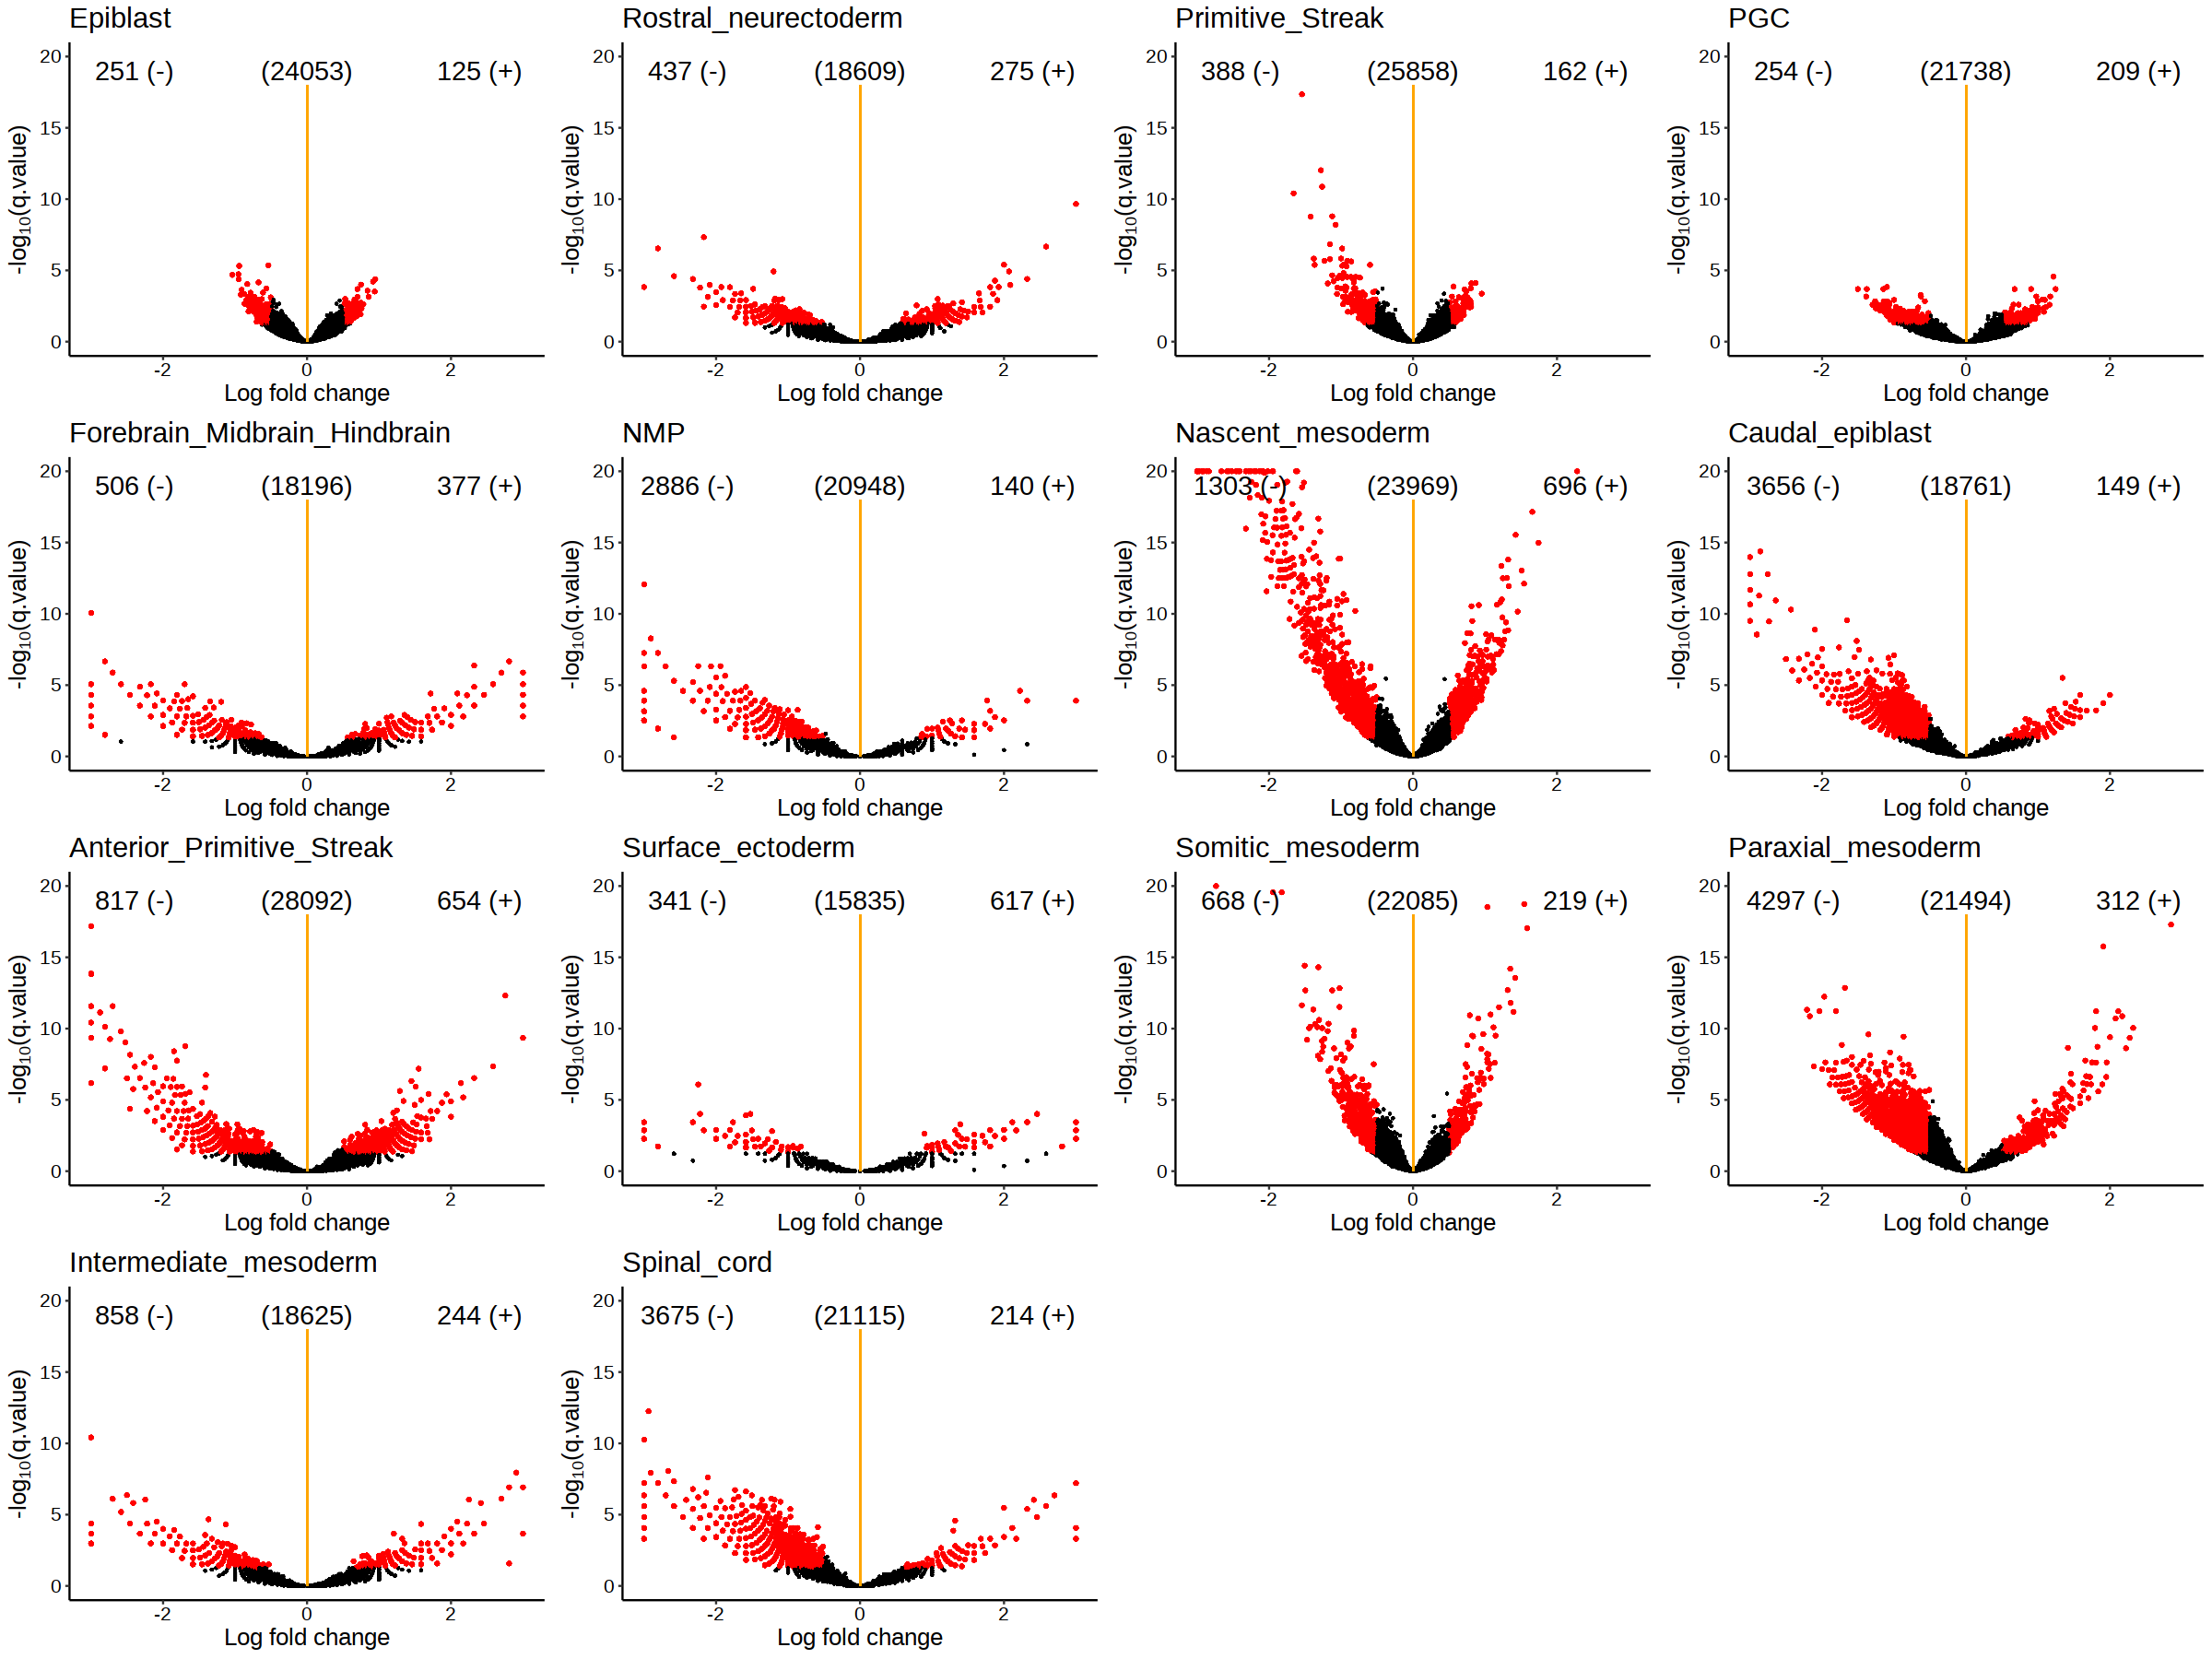

In [74]:
options(repr.plot.width=20, repr.plot.height=15) 
ggarrange(plotlist=DEG_plots_filt)

In [73]:
pdf(sprintf('%s/DAR_volcanos.pdf', args$outdir), width=20, height=15)
     print(ggarrange(plotlist=DEG_plots_filt))
dev.off()

png 
  2

In [88]:
DARs = DARs[celltype!='Epiblast'] # remove epiblast bc most of the WT cells are from D2.5, so unfair comparison

In [27]:
peak_nearby_gene = as.data.table(ArchRProject@peakSet) %>% 
    .[,feature:=paste0(seqnames, ':', start,'-', end)] %>%
    .[,c('feature', 'distToGeneStart', 'nearestGene', 'peakType')]

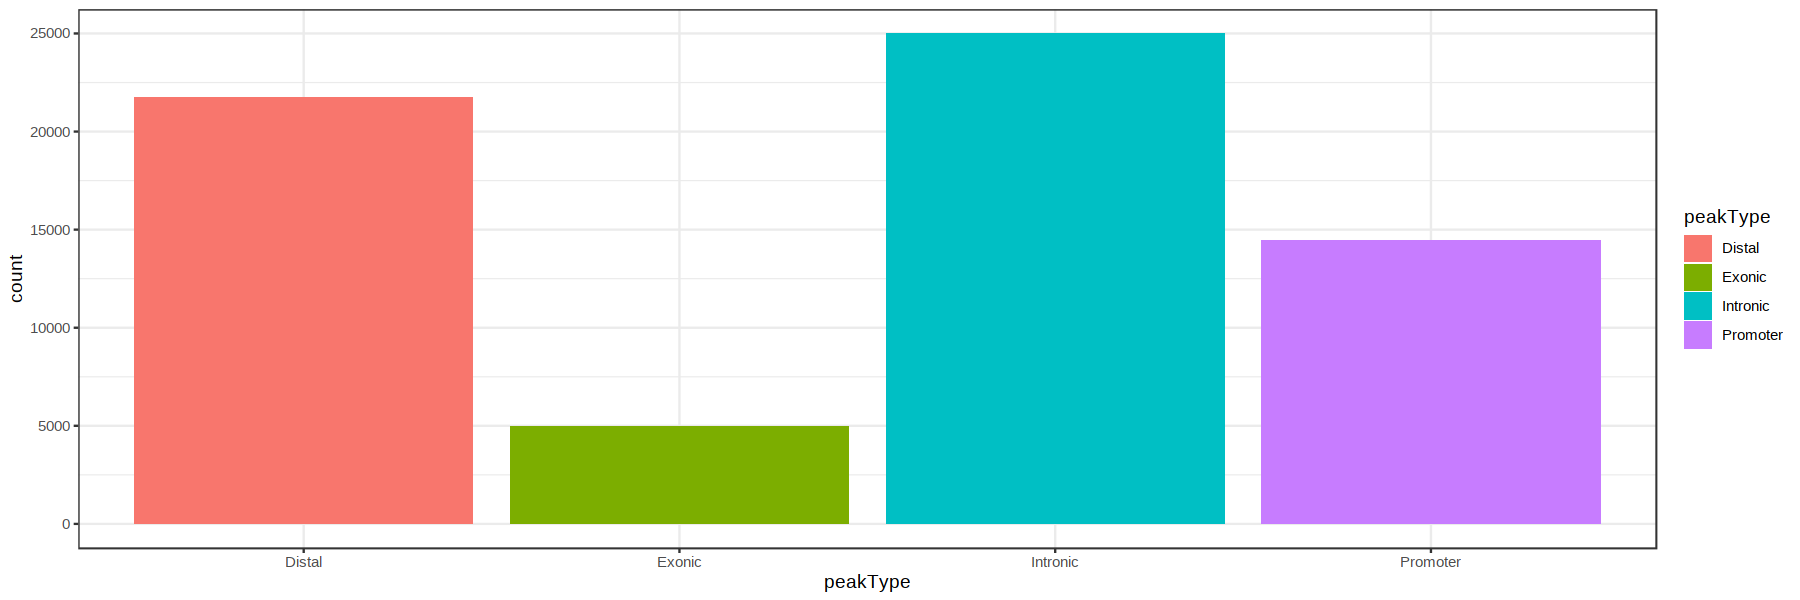

In [28]:
ggplot(peak_nearby_gene, aes(peakType, fill=peakType)) + geom_bar() + theme_bw()

In [29]:
test = DARs %>% 
    .[abs(logFC)>1] %>%
    .[, diff:=ifelse(logFC>0.5 & padj_fdr<0.05, 'up', 
                    ifelse(logFC<=-0.5 & padj_fdr<0.05, 'down', NA))] %>%
    .[!is.na(diff),]

In [30]:
up = merge(test[diff=='up',c('feature', 'celltype')], peak_nearby_gene, by='feature')

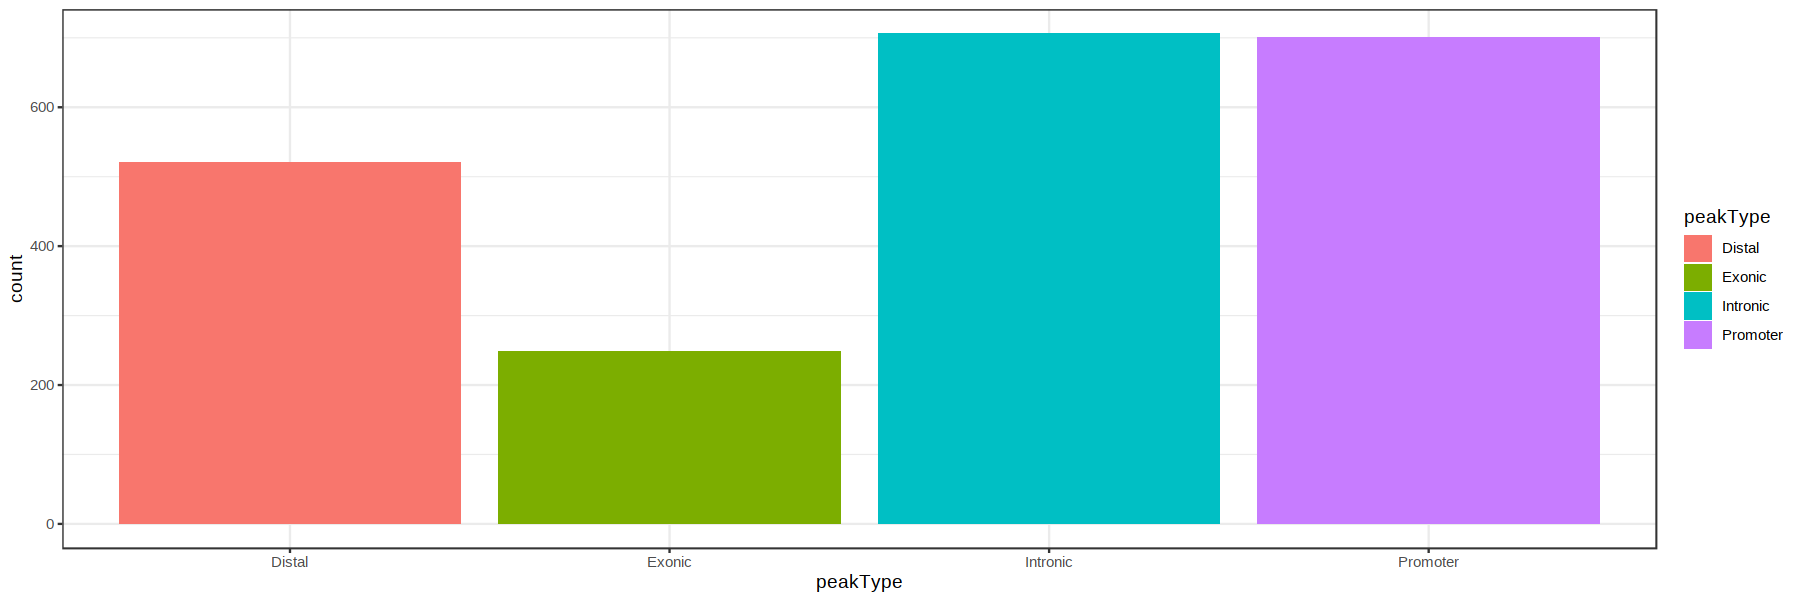

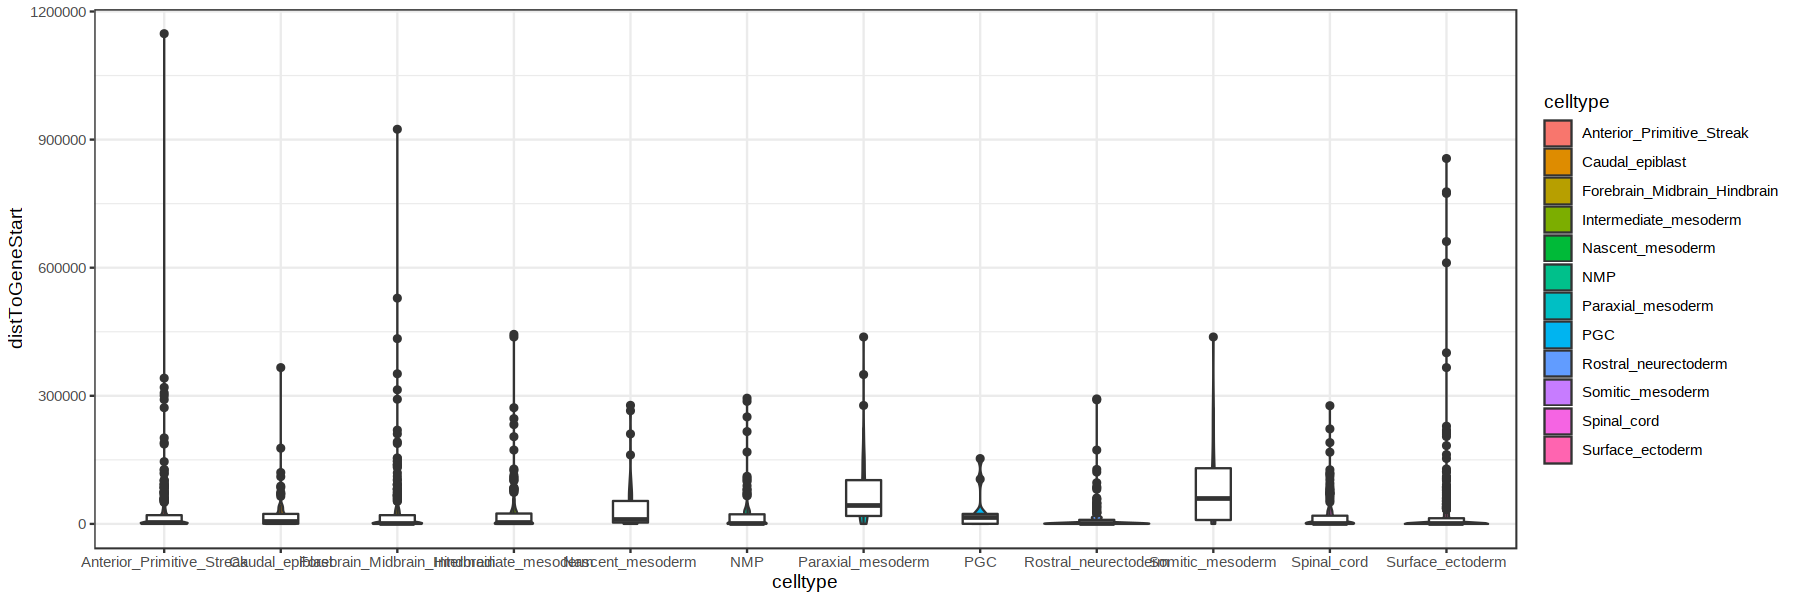

In [31]:
options(repr.plot.width=15, repr.plot.height=5) 
ggplot(up, aes(peakType, fill=peakType)) + geom_bar() + theme_bw()
ggplot(up, aes(celltype, distToGeneStart, fill=celltype)) + geom_violin() + geom_boxplot(fill='white', width=0.3) + theme_bw()

In [32]:
up_genes = up %>% .[, c('feature', 'celltype'):=list(NULL,NULL)] %>% .[,N:=.N, by='nearestGene'] %>% unique(by='nearestGene') %>% .[order(-N)]
head(up_genes,10)

distToGeneStart,nearestGene,peakType,N
<int>,<chr>,<chr>,<int>
4612,Ebf1,Distal,6
1384,Zic5,Exonic,4
9205,Gbx2,Distal,4
250628,Prpf18,Exonic,4
103431,Zdhhc21,Distal,4
1920,Hmga2,Intronic,3
859,Slc35f1,Intronic,3
21801,Sptbn1,Exonic,3
6276,Glra1,Intronic,3


In [33]:
down = merge(test[diff=='down',c('feature', 'celltype')], peak_nearby_gene, by='feature')

Warning message:
“Groups with fewer than two data points have been dropped.”


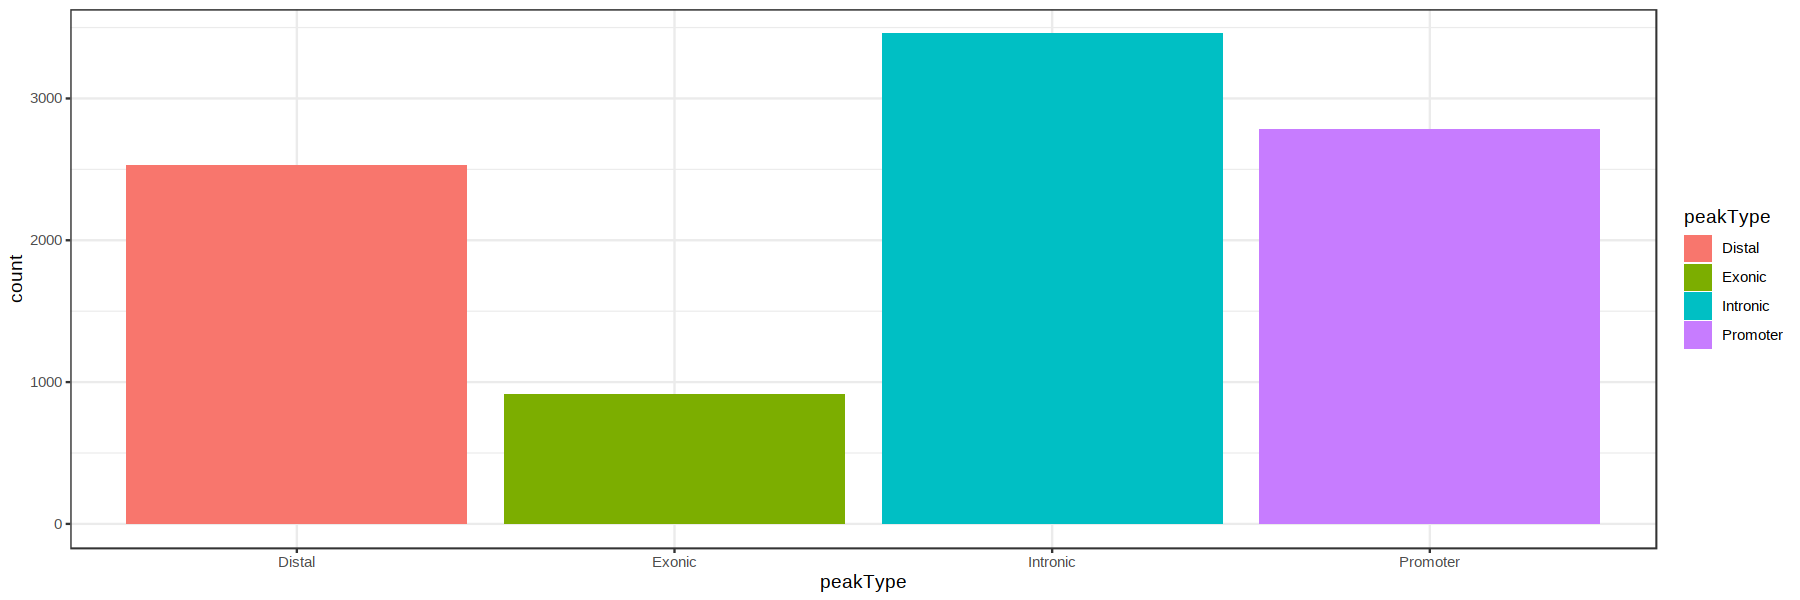

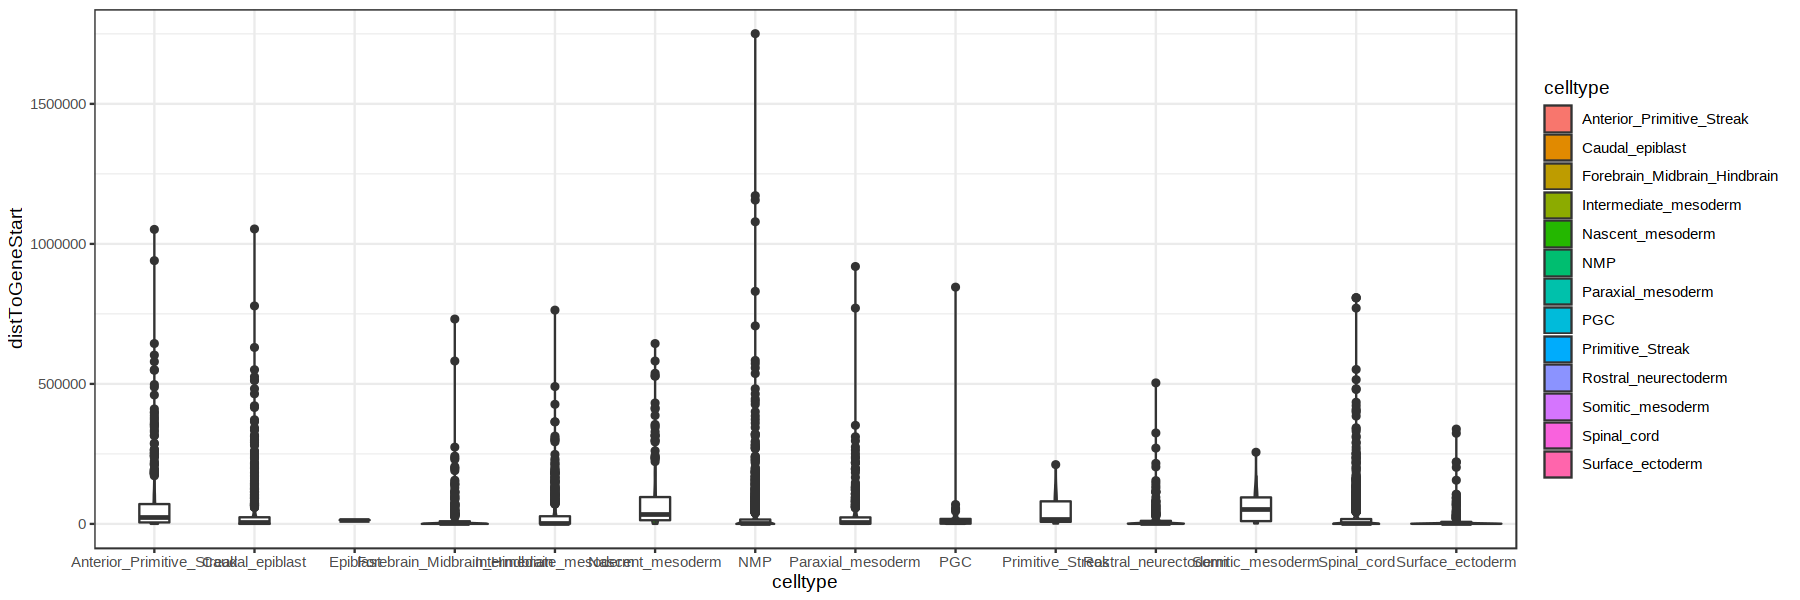

In [34]:
options(repr.plot.width=15, repr.plot.height=5) 
ggplot(down, aes(peakType, fill=peakType)) + geom_bar() + theme_bw()
ggplot(down, aes(celltype, distToGeneStart, fill=celltype)) + geom_violin() + geom_boxplot(fill='white', width=0.3) + theme_bw()

In [35]:
down = merge(test[diff=='down',c('feature', 'celltype')], peak_nearby_gene, by='feature')

In [36]:
# genes that have any downregulated feature, counted by how many celltype.
down_genes = down %>% unique(by=c('celltype', 'nearestGene')) %>% .[, c('feature', 'celltype'):=list(NULL,NULL)] %>% .[,N:=.N, by='nearestGene'] %>% unique(by='nearestGene') %>% .[order(-N)]

In [37]:
head(down_genes, 20)

distToGeneStart,nearestGene,peakType,N
<int>,<chr>,<chr>,<int>
220108,Tgif1,Intronic,7
26089,Epha2,Distal,7
343383,Samd5,Distal,6
797,Kif26a,Promoter,6
39793,Rps24,Distal,6
4790,Cbx7,Intronic,6
37559,Foxp4,Intronic,6
177030,2610028E06Rik,Distal,6
6219,Ncor2,Intronic,6


In [38]:
down_genes$nearestGene

[1] "Tgif1"         "Epha2"         "Samd5"         "Kif26a"       
   [5] "Rps24"         "Cbx7"          "Foxp4"         "2610028E06Rik"
   [9] "Ncor2"         "Zfp703"        "Wnt3"          "Grin2c"       
  [13] "Lgals3bp"      "Hs3st3b1"      "9630013K17Rik" "Gli3"         
  [17] "Ptch1"         "1700024I08Rik" "Irx1"          "Mgat3"        
  [21] "Opa1"          "Slit1"         "Fzd7"          "March4"       
  [25] "Pax3"          "Gbx2"          "Cops8"         "Shf"          
  [29] "Commd7"        "Mir3089"       "Lmx1b"         "Acot11"       
  [33] "Pax7"          "Chd7"          "E130006D01Rik" "Mnx1"         
  [37] "Cul1"          "Vasp"          "Bnc1"          "Tenm4"        
  [41] "Wnt11"         "A330074K22Rik" "Gse1"          "Cadm1"        
  [45] "Tle3"          "Smad6"         "Bcor"          "Hmga2"        
  [49] "Mthfd1l"       "Unc5b"         "Hkdc1"         "Mir1191b"     
  [53] "Rdm1"          "Cdc42ep4"      "Slc9a3r1"      "Tmc6"         
  [57] "Dnah17"        "Fgf18"         "Mat2b"         "Hand1"        
  [61] "Wnt9a"         "Timm22"        "0610039H22Rik" "Rara"         
  [65] "Gm10432"       "Adssl1"        "Esyt2"         "Dnmt3a"       
  [69] "Arl4a"         "9430078K24Rik" "Pnma1"         "Mir1904"      
  [73] "Plpp1"         "Ly86"          "Hsd17b3"       "4930572O13Rik"
  [77] "Ptp4a3"        "Adgrb1"        "Gm36738"       "Tbx1"         
  [81] "Cpn2"          "Srsf3"         "Pkdcc"         "2010106C02Rik"
  [85] "Calm2"         "Cxxc5"         "Mbp"           "Myof"         
  [89] "Pax2"          "Gli2"          "En1"           "Ier5"         
  [93] "Kif26b"        "Lbr"           "Gm973"         "Sumo1"        
  [97] "Mir375"        "Asic4"         "Twist2"        "G630016G05Rik"
 [101] "Foxa2"         "Vstm2l"        "Tfap2c"        "Pkn3"         
 [105] "Fam102a"       "C130021I20Rik" "Dlx2"          "Trp53i11"     
 [109] "Alx4"          "Mannr"         "Fxr1"          "Maml3"        
 [113] "Ppm1l"         "Hey1"          "Ssbp3"         "Tmem53"       
 [117] "Pou3f1"        "Lin28a"        "Dhrs3"         "Mmel1"        
 [121] "Rgs3"          "Clvs1"         "Pitpnb"        "Gtf2ird1"     
 [125] "Sh2b2"         "Trim56"        "Fam20c"        "Sema3e"       
 [129] "Fbxl14"        "Itpr2"         "Smo"           "Emx1"         
 [133] "Tpra1"         "Slc6a6"        "Btbd10"        "Bbc3"         
 [137] "Pnmal2"        "Kcnc3"         "Atf5"          "Ftl1"         
 [141] "Wdr73"         "B930025P03Rik" "Adamts18"      "Irf8"         
 [145] "Mir3106"       "Dusp4"         "Trmt9b"        "Tll1"         
 [149] "Comp"          "Ier2"          "Zfp423"        "Irx3"         
 [153] "Cacna2d2"      "Pknox2"        "Sorl1"         "Nectin1"      
 [157] "Rplp1"         "Zic3"          "Grip1"         "Lrig3"        
 [161] "Agap2"         "B4galnt1"      "Gli1"          "Shmt2"        
 [165] "Nhsl1"         "Foxo3"         "Sobp"          "Spock2"       
 [169] "Nodal"         "Col13a1"       "1110002J07Rik" "Fam207a"      
 [173] "Ptbp1"         "Tmem259"       "Mex3d"         "Nfic"         
 [177] "Aes"           "4930463O16Rik" "Nt5dc3"        "Mir7211"      
 [181] "Dusp6"         "Ubtf"          "Itga2b"        "Mgat5b"       
 [185] "Gm11729"       "6030468B19Rik" "Fignl1"        "Engase"       
 [189] "Mir1932"       "2810410L24Rik" "Bahcc1"        "Cobl"         
 [193] "Meis1"         "Slc1a4"        "Sertad2"       "Bcl11a"       
 [197] "Trim41"        "Maml1"         "Pdlim4"        "Sparc"        
 [201] "Mapk7"         "Zkscan6"       "Mir6406"       "Per1"         
 [205] "Rap1gap2"      "Mnt"           "Mrm3"          "Bhlha9"       
 [209] "Mrps23"        "Tac4"          "Igf2bp1"       "Sp8"          
 [213] "Gm34637"       "Odc1"          "Eipr1"         "Adcy3"        
 [217] "Pax9"          "Foxa1"         "Six1"          "Zbtb25"       
 [221] "Zfp36l1"       "Actn1"         "Rgs6"          "Hs1bp3"       
 [225] "Mlh3"          "Fox

In [41]:
DARs_filt = DARs[,sig:=ifelse(abs(logFC)>0.5 & padj_fdr<0.05, TRUE, FALSE)] %>% .[sig==TRUE]

In [48]:
length(unique(DARs_filt$feature))

[1] 18286

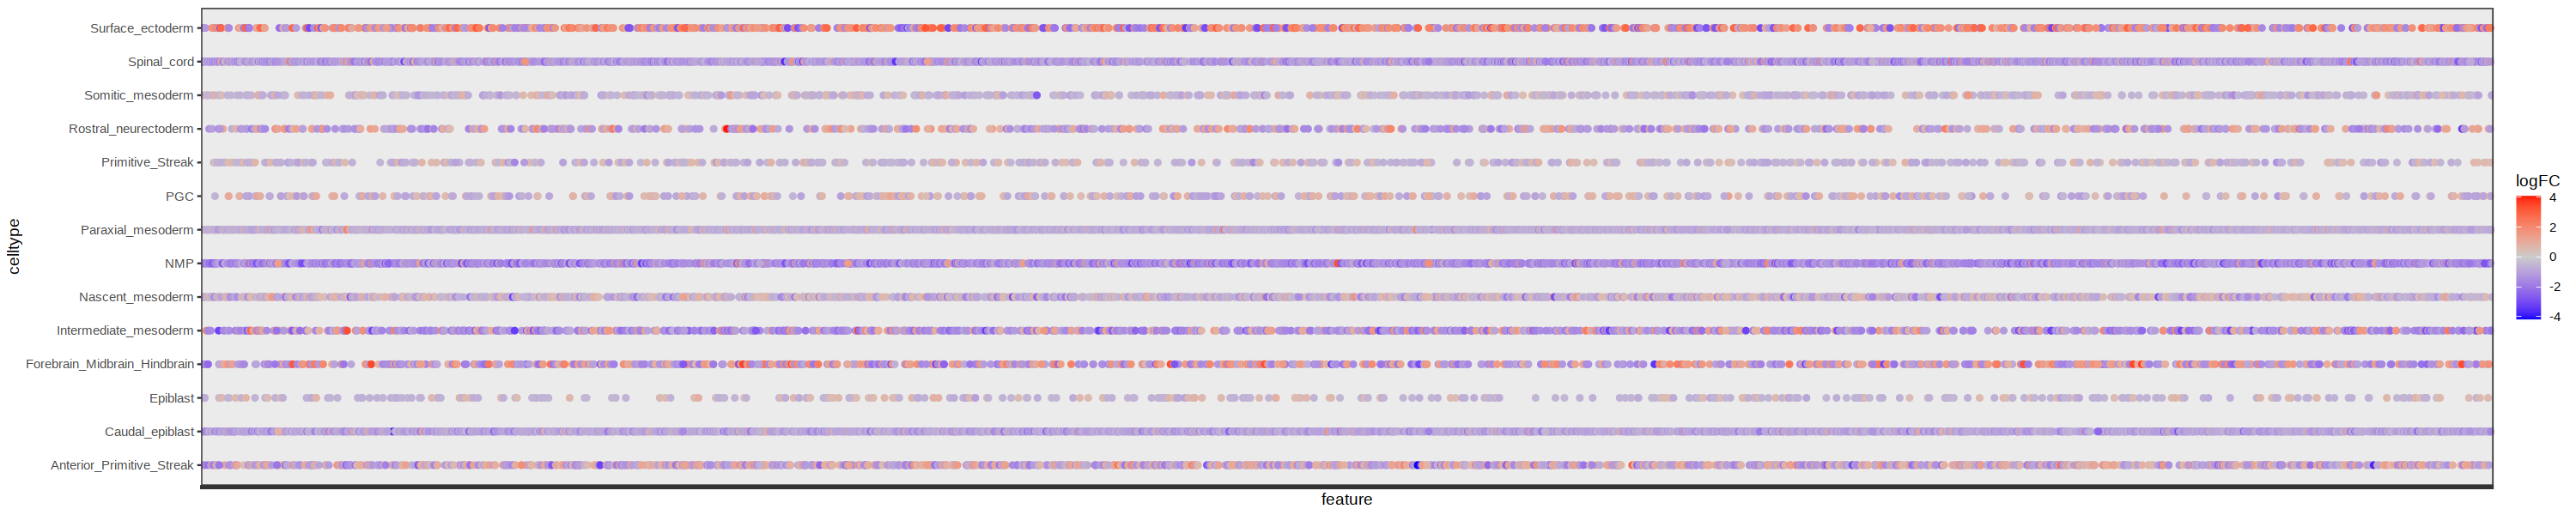

In [47]:
options(repr.plot.width=25, repr.plot.height=5) 
ggplot(DARs_filt, aes(feature, celltype, col=logFC)) +  #, size= -log10(padj_fdr)
    geom_point() + 
    scale_color_gradient2(low='blue', mid='grey80', high='red') + 
    theme_bw() + 
    theme(axis.text.x=element_blank())

# Heatmap

In [110]:
heatmap.features = DARs %>% 
    .[abs(logFC)>1.5] %>%
    .[, diff:=ifelse(logFC>=1 & padj_fdr<0.05, 'up', 
                    ifelse(logFC<=1 & padj_fdr<0.05, 'down', NA))] %>%
    .[!is.na(diff),]

In [111]:
atac.se.heatmap = atac.se[heatmap.features$feature]

In [112]:
means = lapply(unique(colData(atac.se.heatmap)$celltype_genotype), function(ct_gt){
    tmp = atac.se.heatmap[,colData(atac.se.heatmap)$celltype_genotype == ct_gt]
    mean = as.matrix(rowMeans(logcounts(tmp)))
    colnames(mean) = ct_gt
    return(mean)
    })

In [113]:
means.mtx = do.call('cbind', means)

In [114]:
library(ComplexHeatmap)

Loading required package: grid

ComplexHeatmap version 2.10.0
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published research, please cite:
Gu, Z. Complex heatmaps reveal patterns and correlations in multidimensional 
  genomic data. Bioinformatics 2016.

The new InteractiveComplexHeatmap package can directly export static 
complex heatmaps into an interactive Shiny app with zero effort. Have a try!

This message can be suppressed by:
  suppressPackageStartupMessages(library(ComplexHeatmap))




In [115]:
meta = as.data.table(colData(atac.se.heatmap)) %>% unique(by='celltype_genotype')

In [119]:
#top annotation
anno <- HeatmapAnnotation(df=meta[,c('celltype', 'genotype')], 
                          col = list(genotype=c("WT"="#00afbb", "Eomes_KO"="#fc4e07"), 
                                     celltype=opts$celltype.color),
                          annotation_legend_param = list(title_gp = gpar(fontsize = 12),
                                                         labels_gp = gpar(fontsize = 12)))

In [120]:
means.mtx <- t(scale(t(means.mtx)))

`use_raster` is automatically set to TRUE for a matrix with more than
2000 rows. You can control `use_raster` argument by explicitly setting
TRUE/FALSE to it.

Set `ht_opt$message = FALSE` to turn off this message.



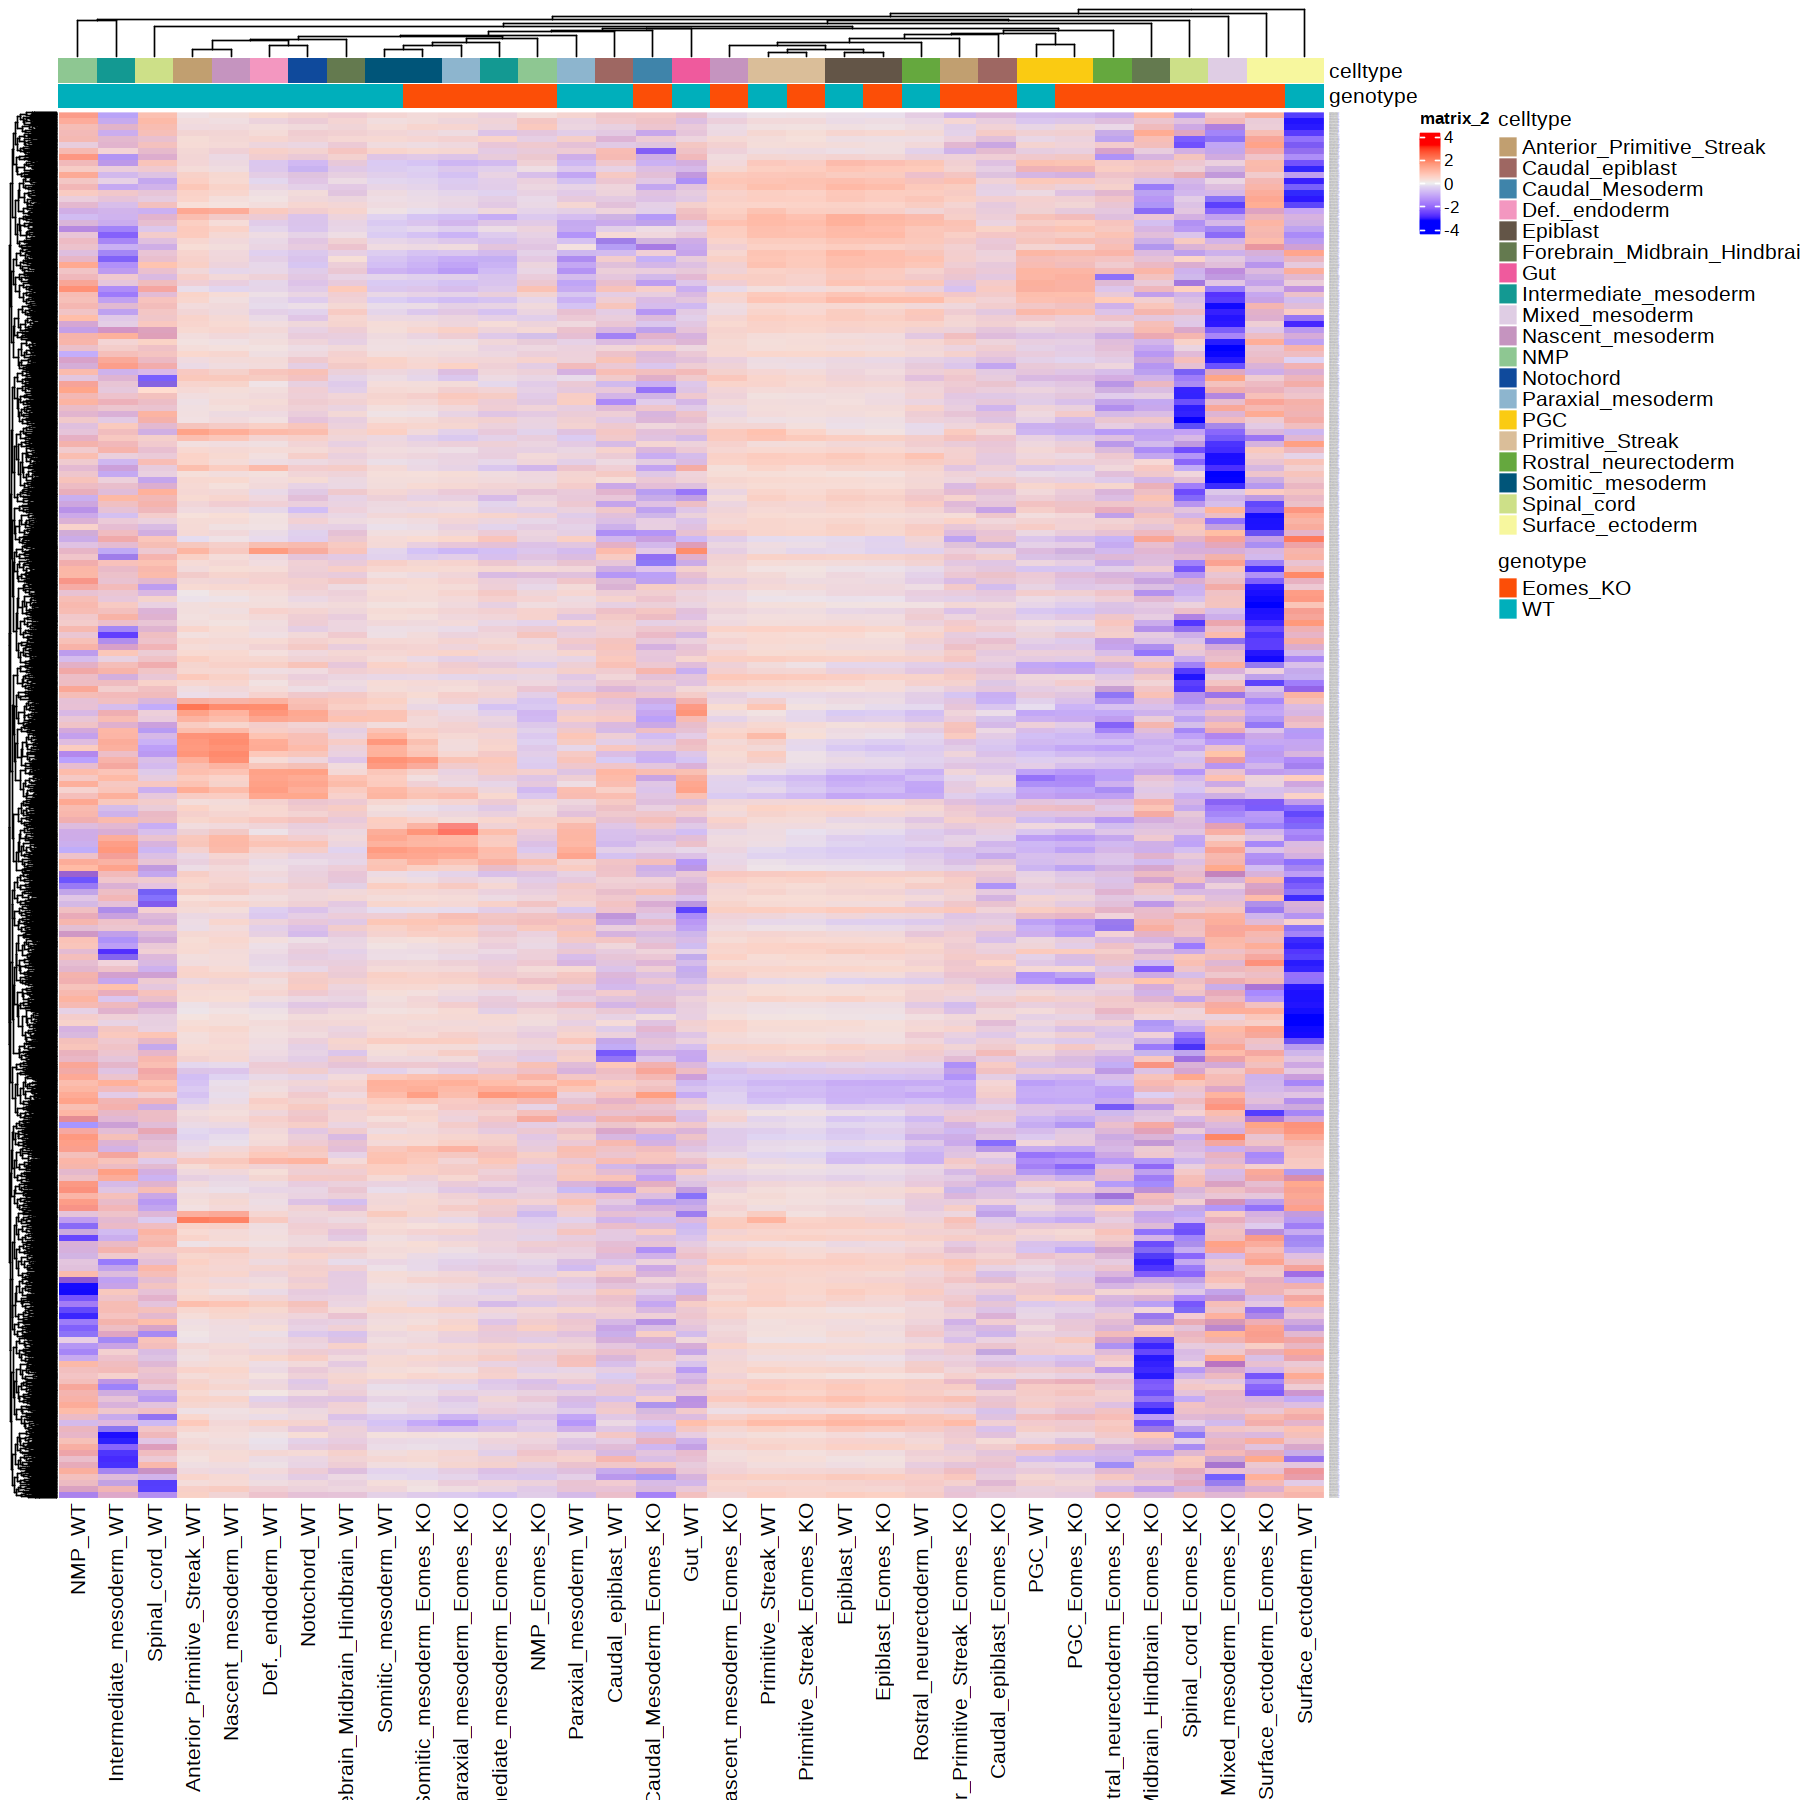

In [121]:
options(repr.plot.width=15, repr.plot.height=15) 

Heatmap(means.mtx, 
        top_annotation = anno,
        cluster_columns = T,
        row_names_gp = gpar(fontsize = 0))

# Up & Down motifs

### Idea

make these types of graphs but instead of indicates motifs up in a celltype, indicate motifs up in Eomes-KO in that celltype, same for downregulated 

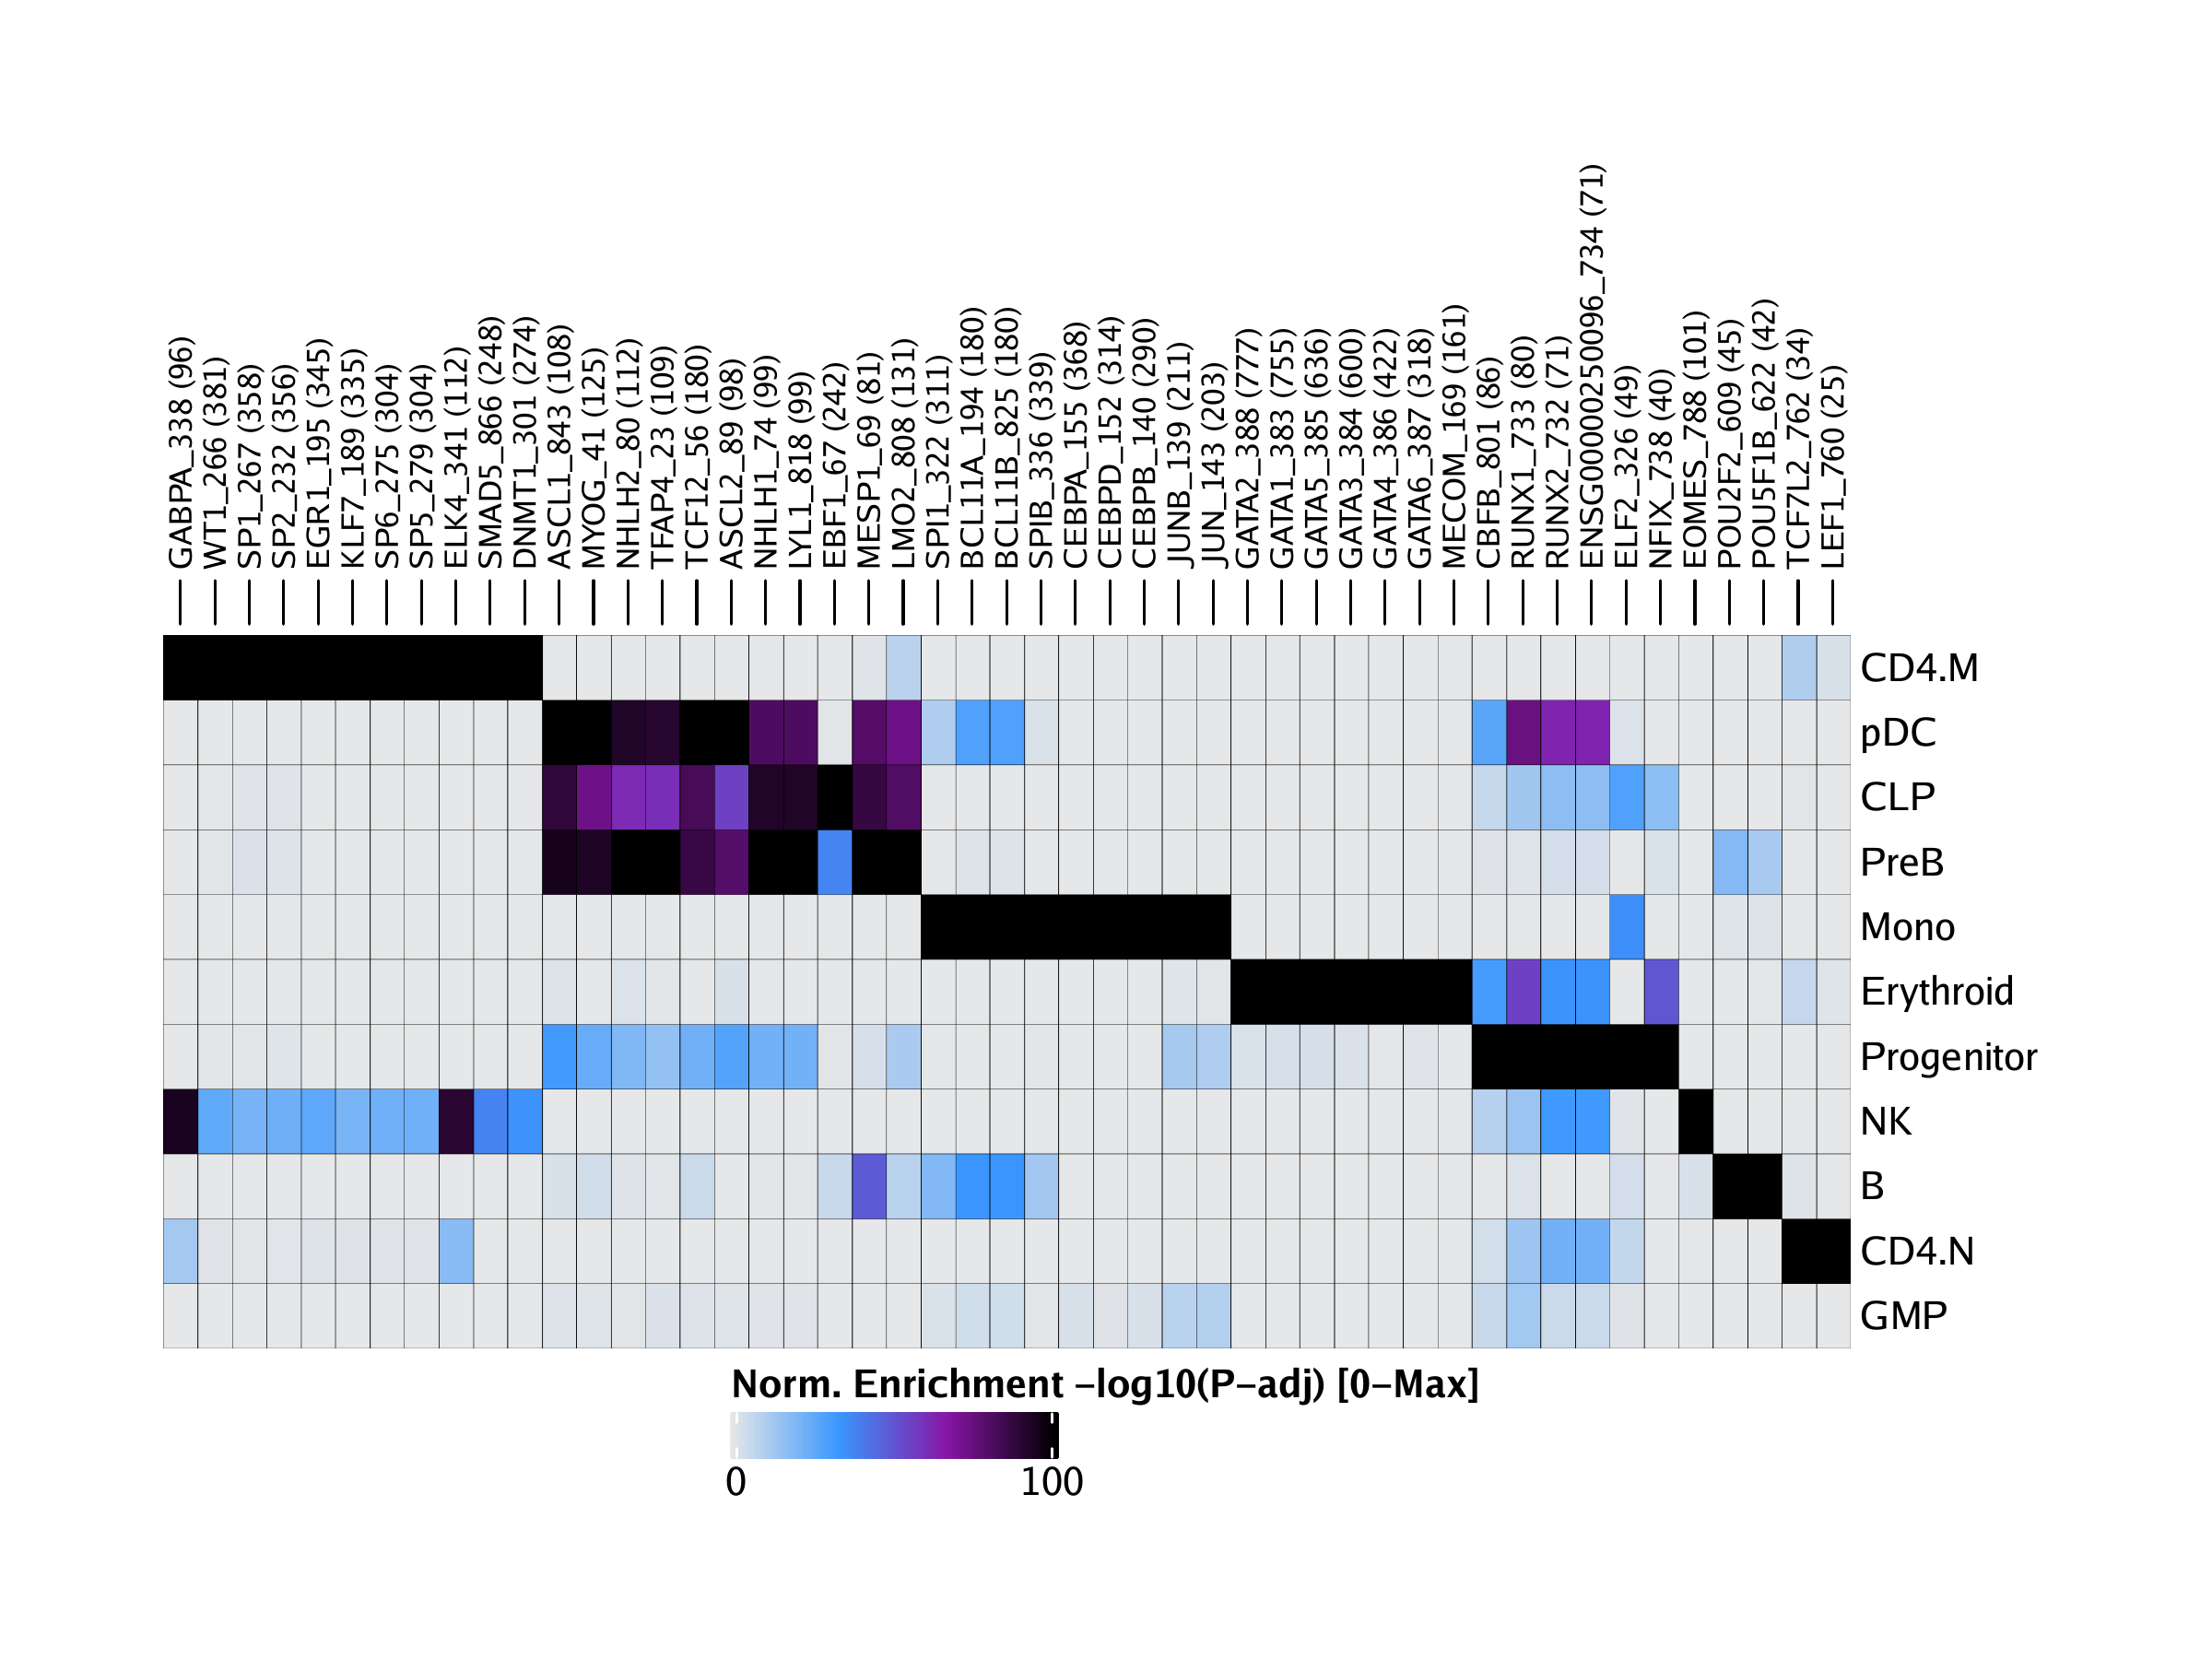


In [168]:
DARs = fread(file.path(io$basedir, 'results/atac/archR/differential/DARs.txt.gz'))

In [140]:
matches = readRDS(file.path(io$basedir, 'processed/atac/archR/Annotations/peakAnnotation.rds'))

In [141]:
ArchRProject@peakAnnotation = matches

In [142]:
ct = 'Epiblast'
markers = getMarkerFeatures(
          ArchRProj = ArchRProject, 
          useMatrix = "PeakMatrix",
          groupBy = "celltype_genotype",
          testMethod = "binomial",
          binarize=TRUE,
          bias = c("TSSEnrichment", "log10(nFrags)"),
          useGroups = paste0(ct, '-Eomes_KO'),
          bgdGroups = paste0(ct, '-WT'),
          verbose= FALSE)

In [143]:
peakset = as.data.table(ArchRProject@peakSet) %>% 
    .[, feature:=paste0(seqnames, ':', start, '-', end)] %>%
    .[,idx:=1:nrow(.)] %>%
    .[,c('feature', 'idx')]

In [169]:
ct_keep = c('Epiblast', 'Primitive_Streak', 'PGC', 'Anterior_Primitive_Streak', 'Nascent_mesoderm', 'Intermediate_mesoderm', 'Somitic_mesoderm', 'Rostral_neurectoderm', 'Forebrain_Midbrain_Hindbrain', 'Surface_ectoderm')
DARs = DARs[celltype %in% ct_keep]

In [170]:
enrich_full = list()
for(i in unique(DARs$celltype)){
        tmp1 = merge(data.table(idx=1:nrow(peakset)), DARs[celltype==i], by='idx', all.x=T) %>%
                        .[,c('Log2FC', 'FDR'):=list(ifelse(is.na(logFC), 0, logFC),
                                                    ifelse(is.na(padj_fdr), 1, padj_fdr))]
    tmp2 = markers
    tmp2@assays@data$Log2FC = data.frame('x'=tmp1$Log2FC)
    tmp2@assays@data$FDR = data.frame('x'=tmp1$FDR)
    colnames(tmp2) = i
    enrich_full[[i]] = tmp2
}
enrich_full = do.call('cbind', enrich_full)

In [146]:
addArchRVerbose(verbose = FALSE)

Setting addArchRVerbose = FALSE



In [148]:
plot_enr_heatmap = function(enrichMotifs, ntop=25) {
    heatmapEM <- plotEnrichHeatmap(enrichMotifs, n = ntop, returnMatrix = TRUE)

    enriched.dt = melt(as.data.table(heatmapEM, keep.rownames=T) %>% setnames('rn', 'TF'), id.vars = c("TF")) %>%
        .[order(-value)] 
    keep_tfs = enriched.dt[, head(.SD, ntop),  by=variable]$TF
    enriched.dt = enriched.dt[TF %in% keep_tfs] %>% .[order( -value)] %>% 
        .[,TF:=strsplit(TF, '_') %>% map_chr(1)] %>%
         .[,TF:=factor(TF, levels=unique(TF))] %>%
        .[,variable:=factor(variable, levels=ct_keep)]
    
    p = ggplot(enriched.dt, aes(TF, variable, fill=value)) + 
    geom_tile(col='black') + 
    viridis::scale_fill_viridis(name='Norm. Enrichment -log10(P-adj) [0-max]') + 
    theme_void() + theme(text=element_text(size=15), 
                         axis.text.x=element_text(angle=-90,hjust=0,vjust=0.5), 
                         axis.text.y=element_text(hjust=1),
                        legend.position='bottom')
    return(p)
}

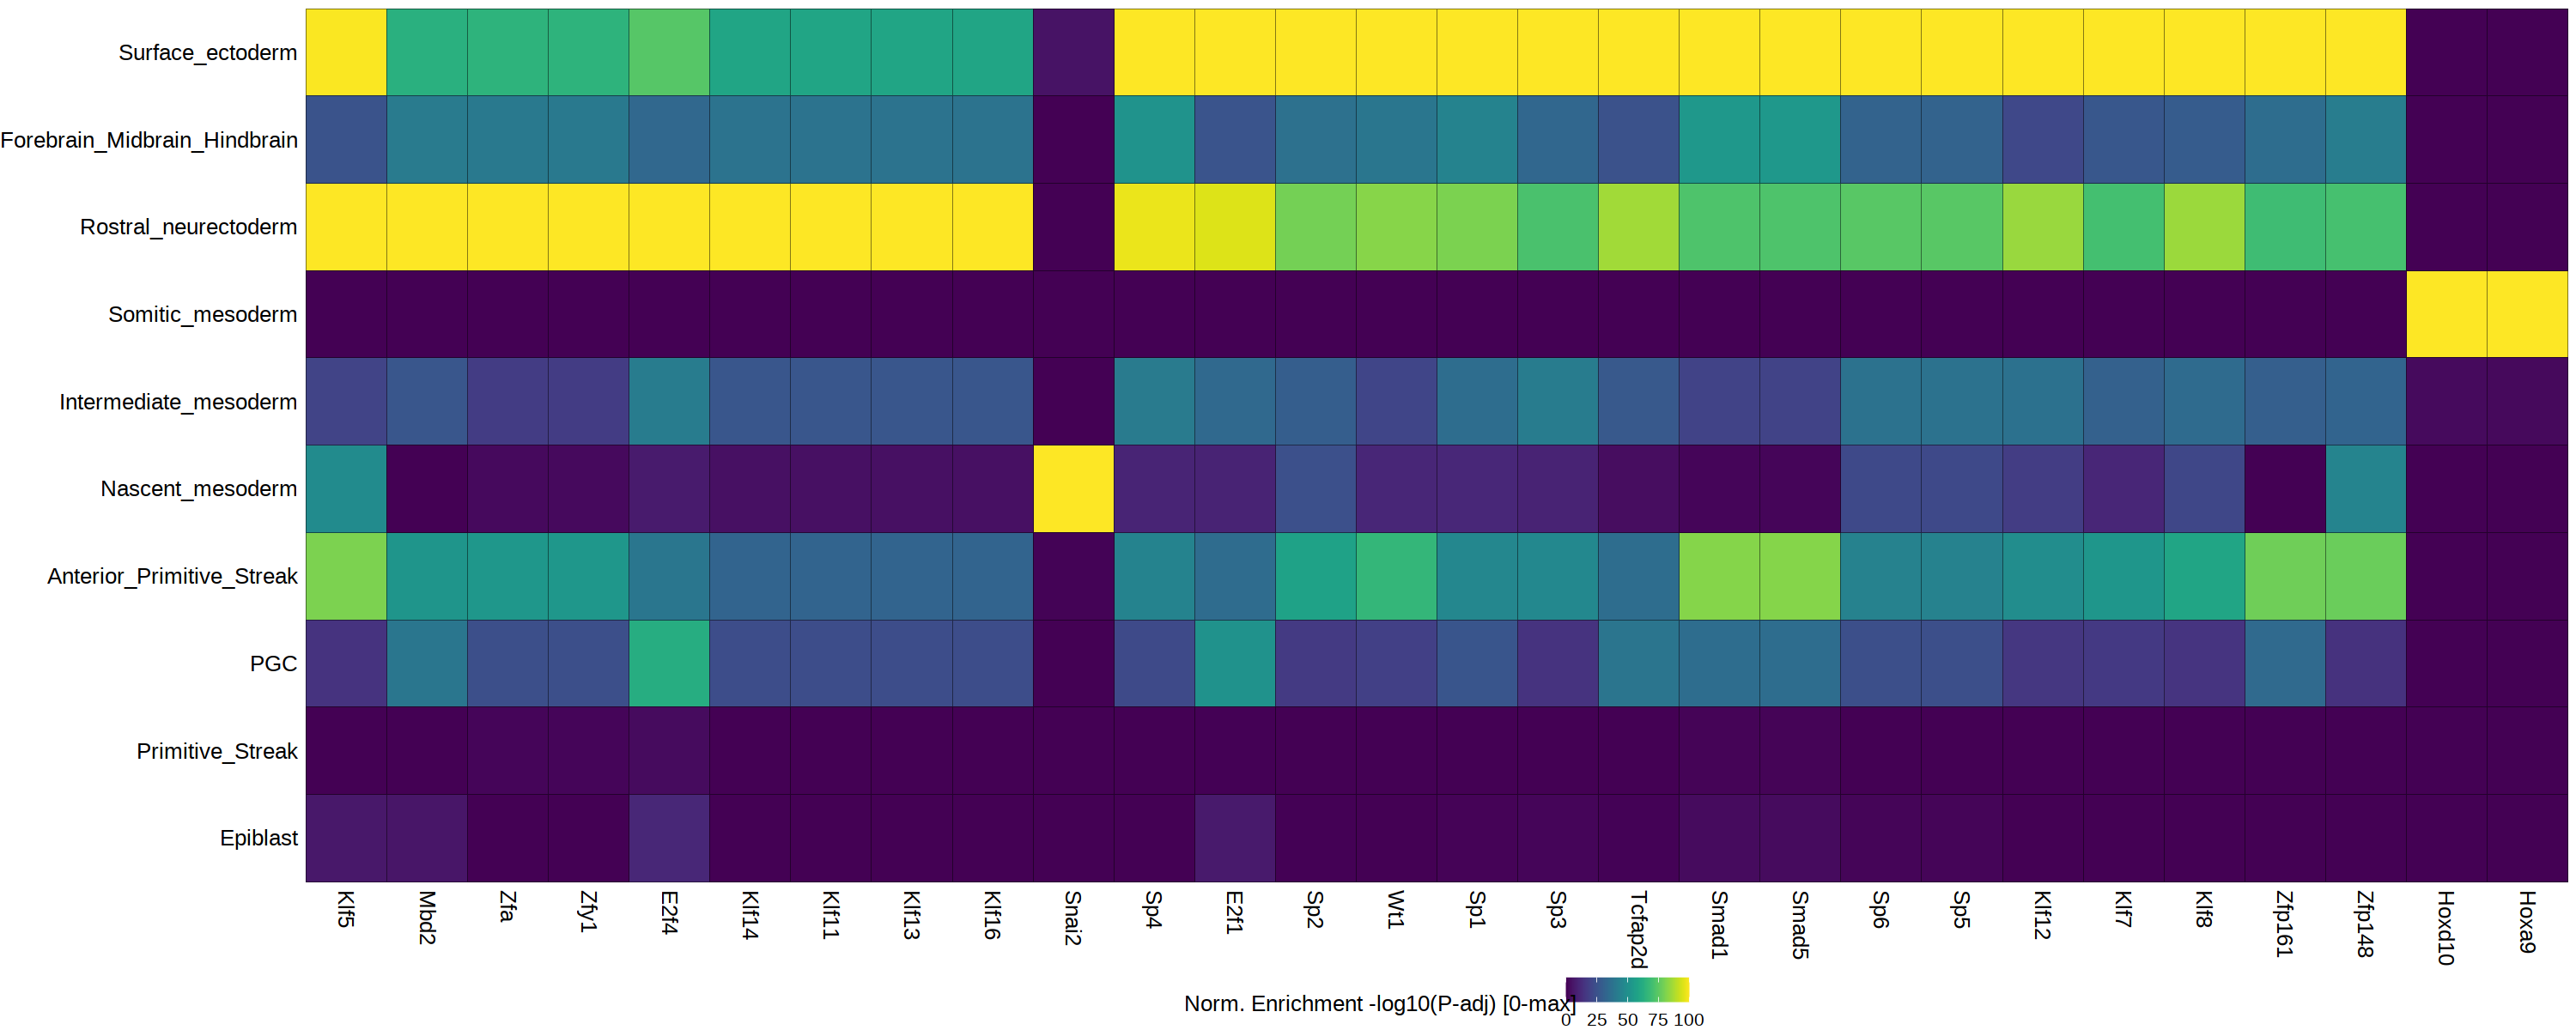

In [175]:
enrichMotifs <- peakAnnoEnrichment(
    seMarker = enrich_full,
    ArchRProj = ArchRProject,
    peakAnnotation = "Motif_cisbp",
    cutOff = "FDR <= 0.1 & Log2FC >=0.5"
  )
options(repr.plot.width=25, repr.plot.height=10)

plot_enr_heatmap(enrichMotifs, ntop = 100)

pdf(sprintf('%s/results/atac/archR/differential/motif_up_celltype_cisbp.pdf', io$basedir), width=23, height=6)
     plot_enr_heatmap(enrichMotifs, ntop = 80)
dev.off()

In [177]:
colnames(enrichMotifs)

[1] "Epiblast"                     "Rostral_neurectoderm"        
 [3] "Primitive_Streak"             "PGC"                         
 [5] "Forebrain_Midbrain_Hindbrain" "Nascent_mesoderm"            
 [7] "Anterior_Primitive_Streak"    "Surface_ectoderm"            
 [9] "Somitic_mesoderm"             "Intermediate_mesoderm"

png 
  2

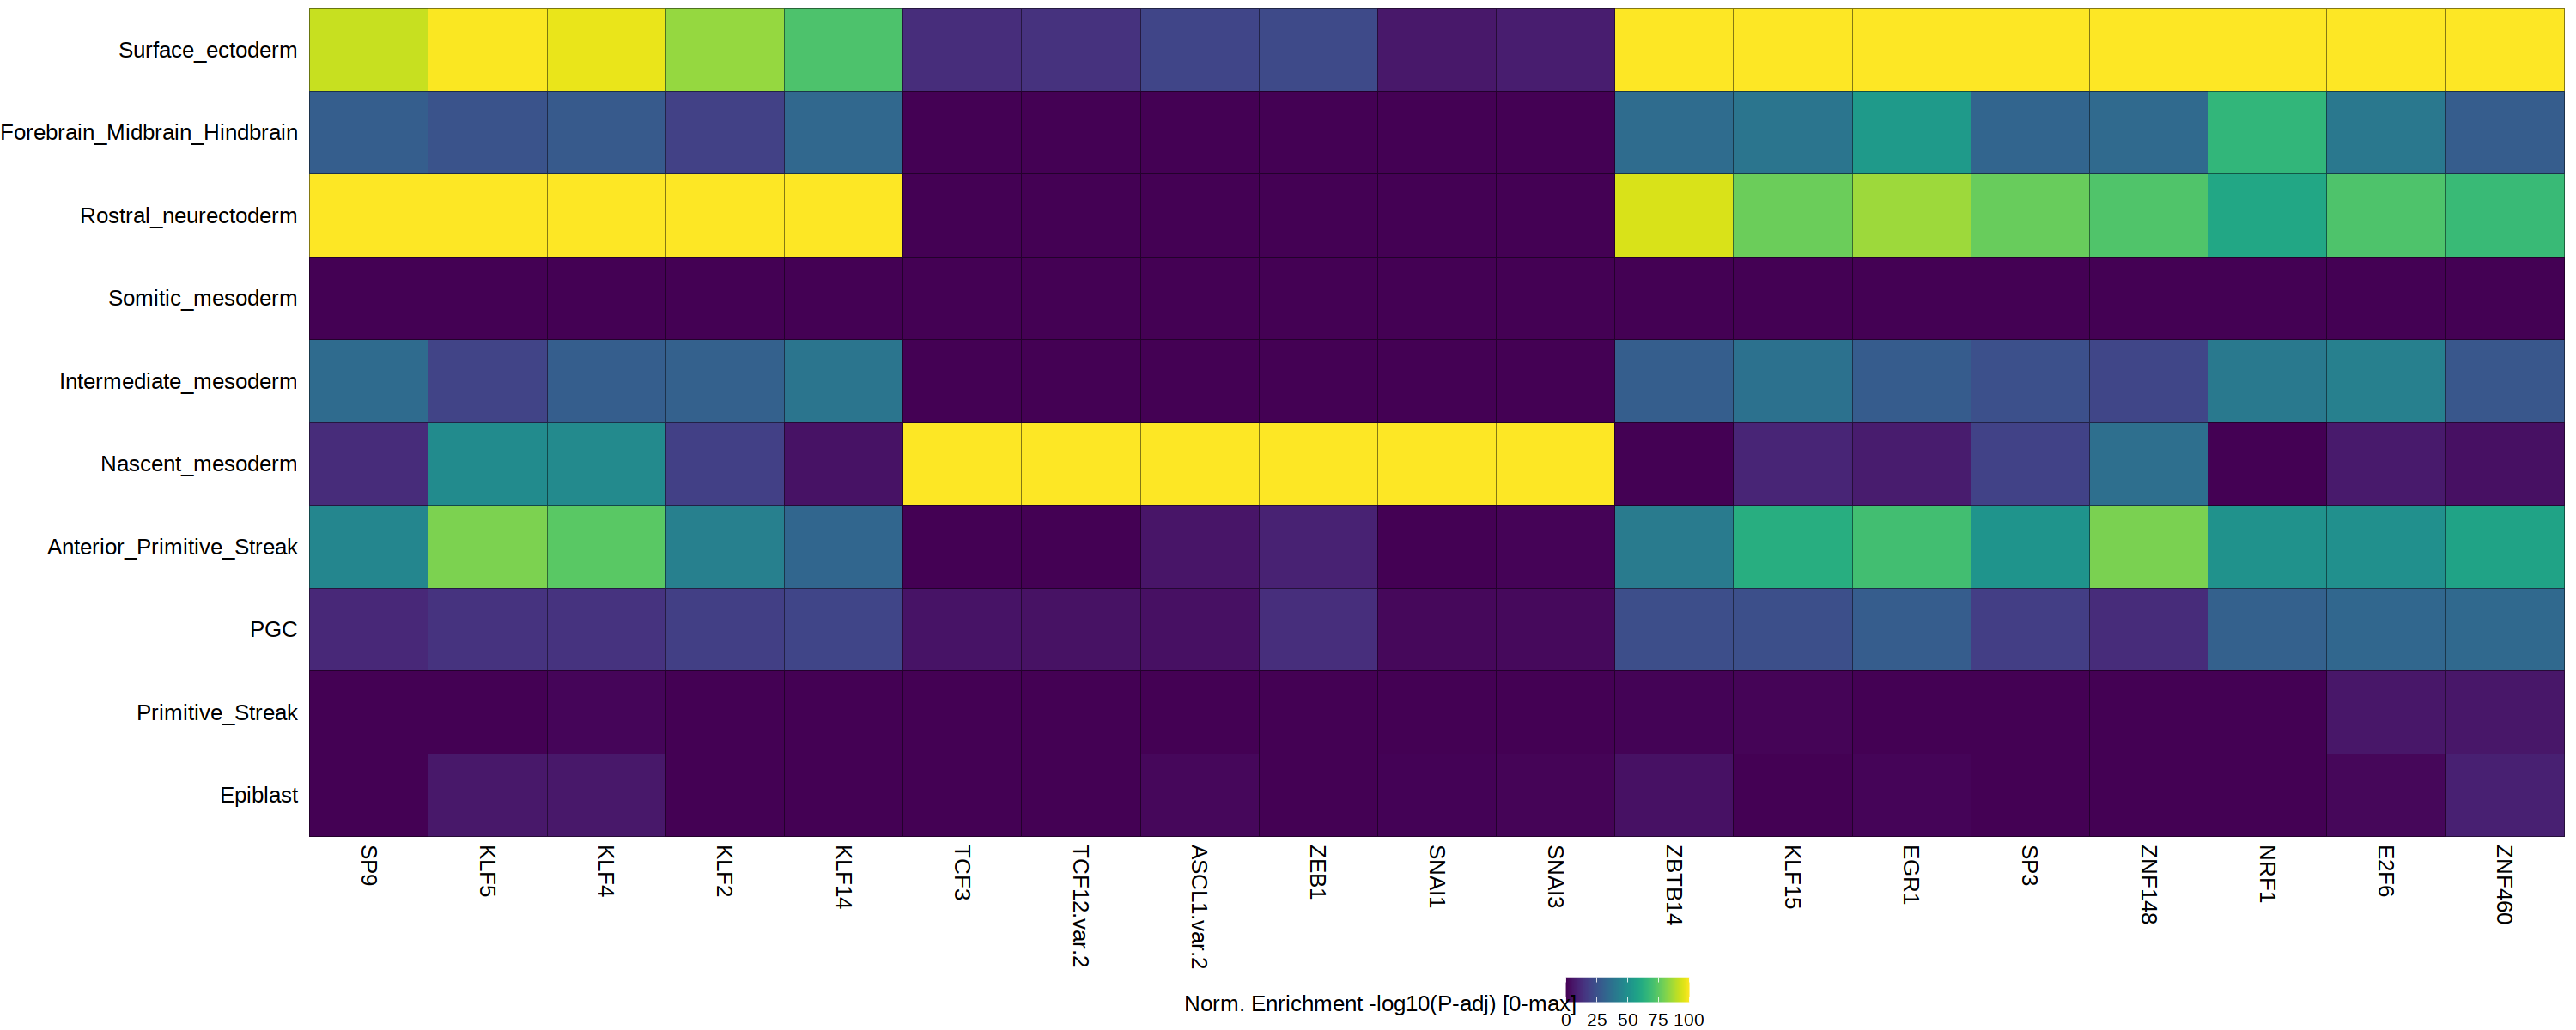

In [193]:
enrichMotifs <- peakAnnoEnrichment(
    seMarker = enrich_full,
    ArchRProj = ArchRProject,
    peakAnnotation = "Motif_JASPAR2020",
    cutOff = "FDR <= 0.1 & Log2FC >= 0.5"
  )
options(repr.plot.width=25, repr.plot.height=10)
plot_enr_heatmap(enrichMotifs, ntop = 80)

pdf(sprintf('%s/results/atac/archR/differential/motif_up_celltype_jaspar.pdf', io$basedir), width=23, height=6)
     plot_enr_heatmap(enrichMotifs, ntop = 80)
dev.off()

png 
  2

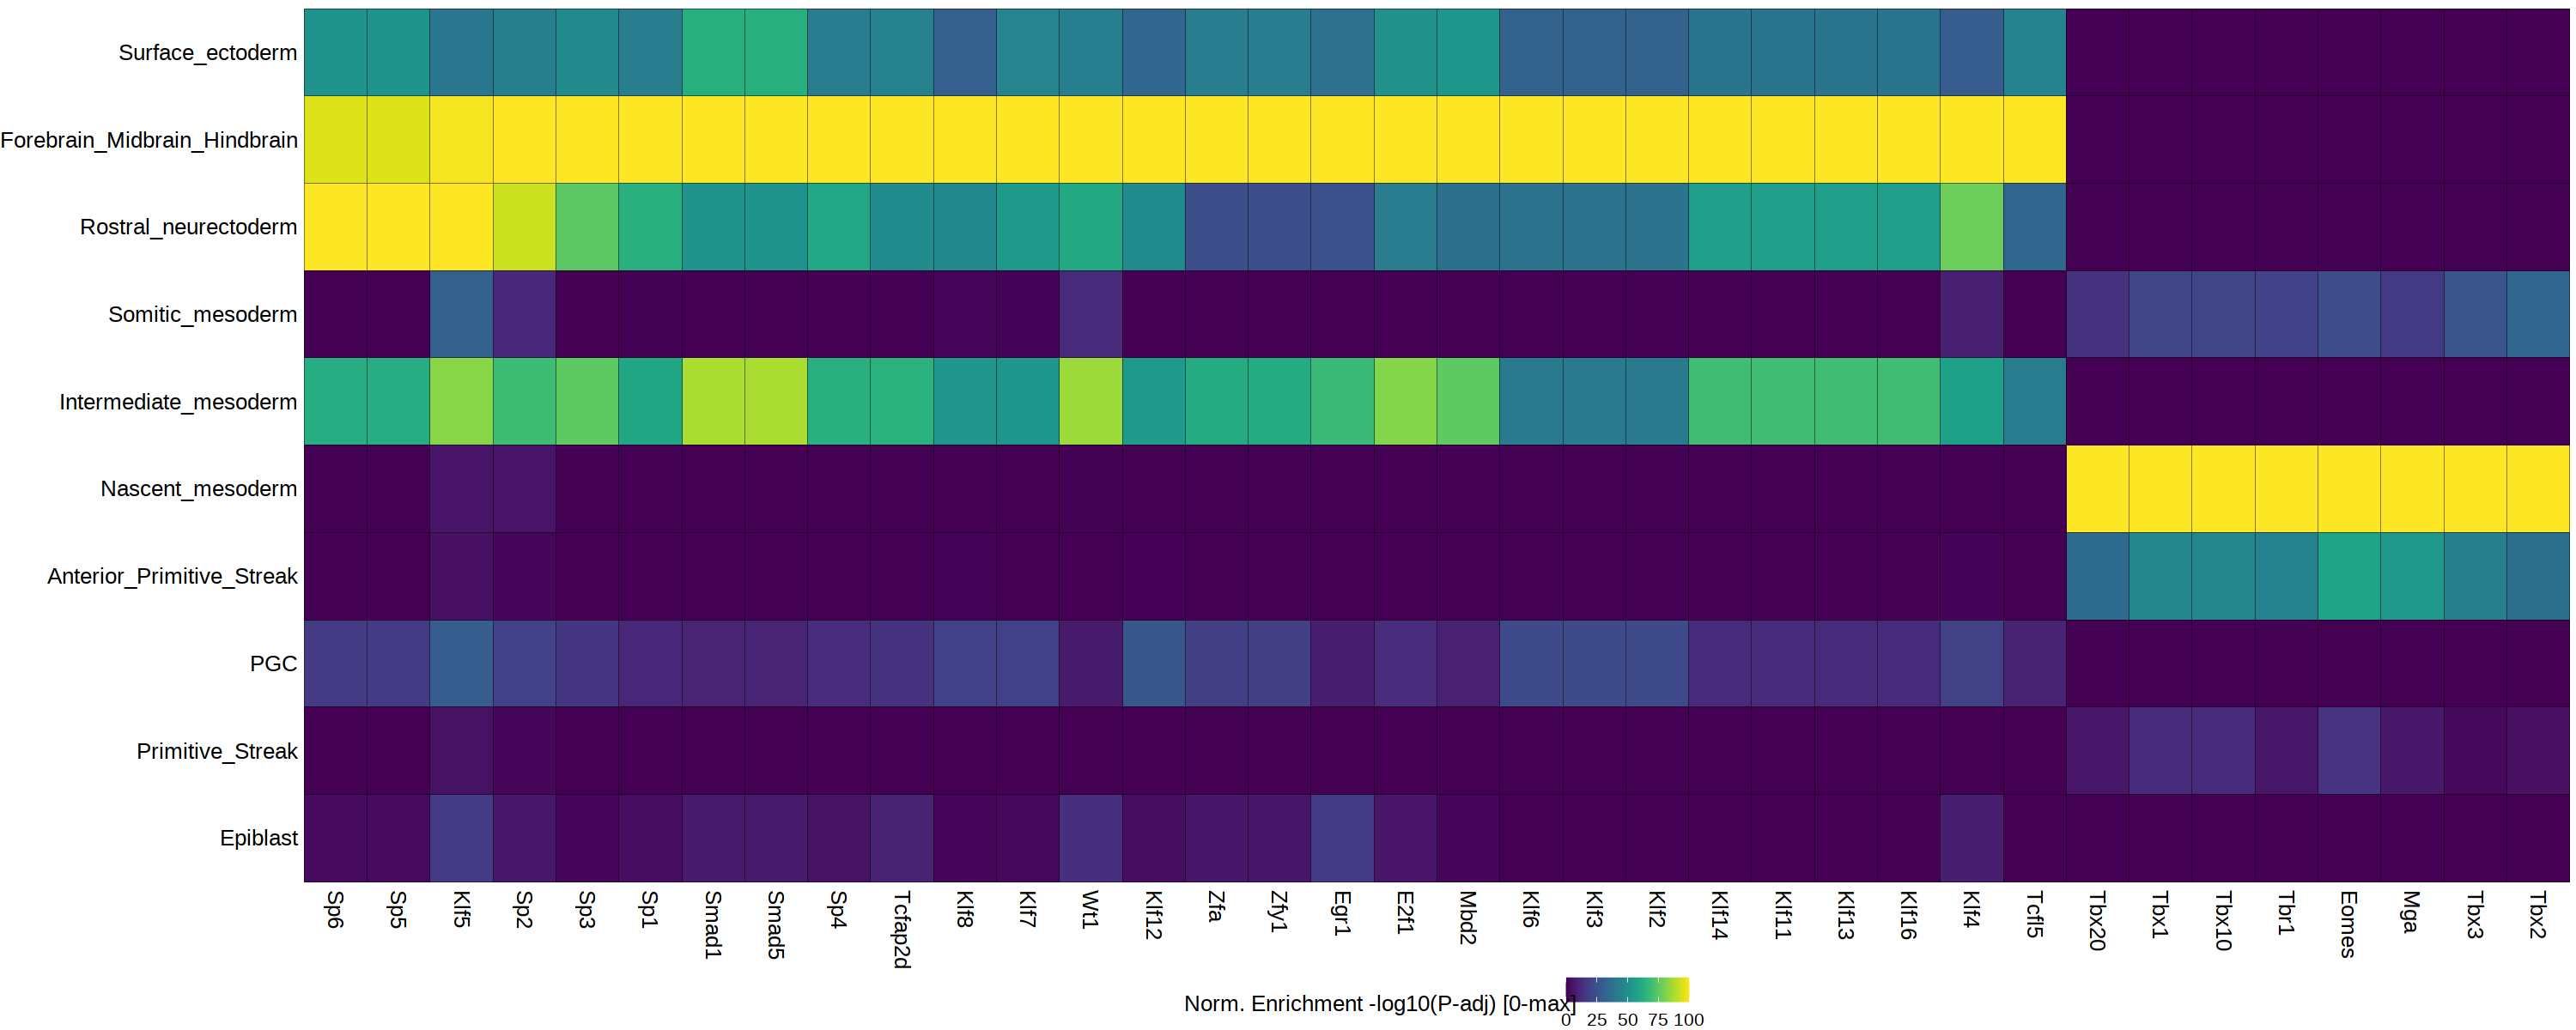

In [195]:
enrichMotifs <- peakAnnoEnrichment(
    seMarker = enrich_full,
    ArchRProj = ArchRProject,
    peakAnnotation = "Motif_cisbp",
    cutOff = "FDR <= 0.1 & Log2FC <= -0.5"
  )

plot_enr_heatmap(enrichMotifs, ntop = 50)

pdf(sprintf('%s/results/atac/archR/differential/motif_down_celltype_cisbp.pdf', io$basedir), width=23, height=6)
     plot_enr_heatmap(enrichMotifs, ntop = 80)
dev.off()

png 
  2

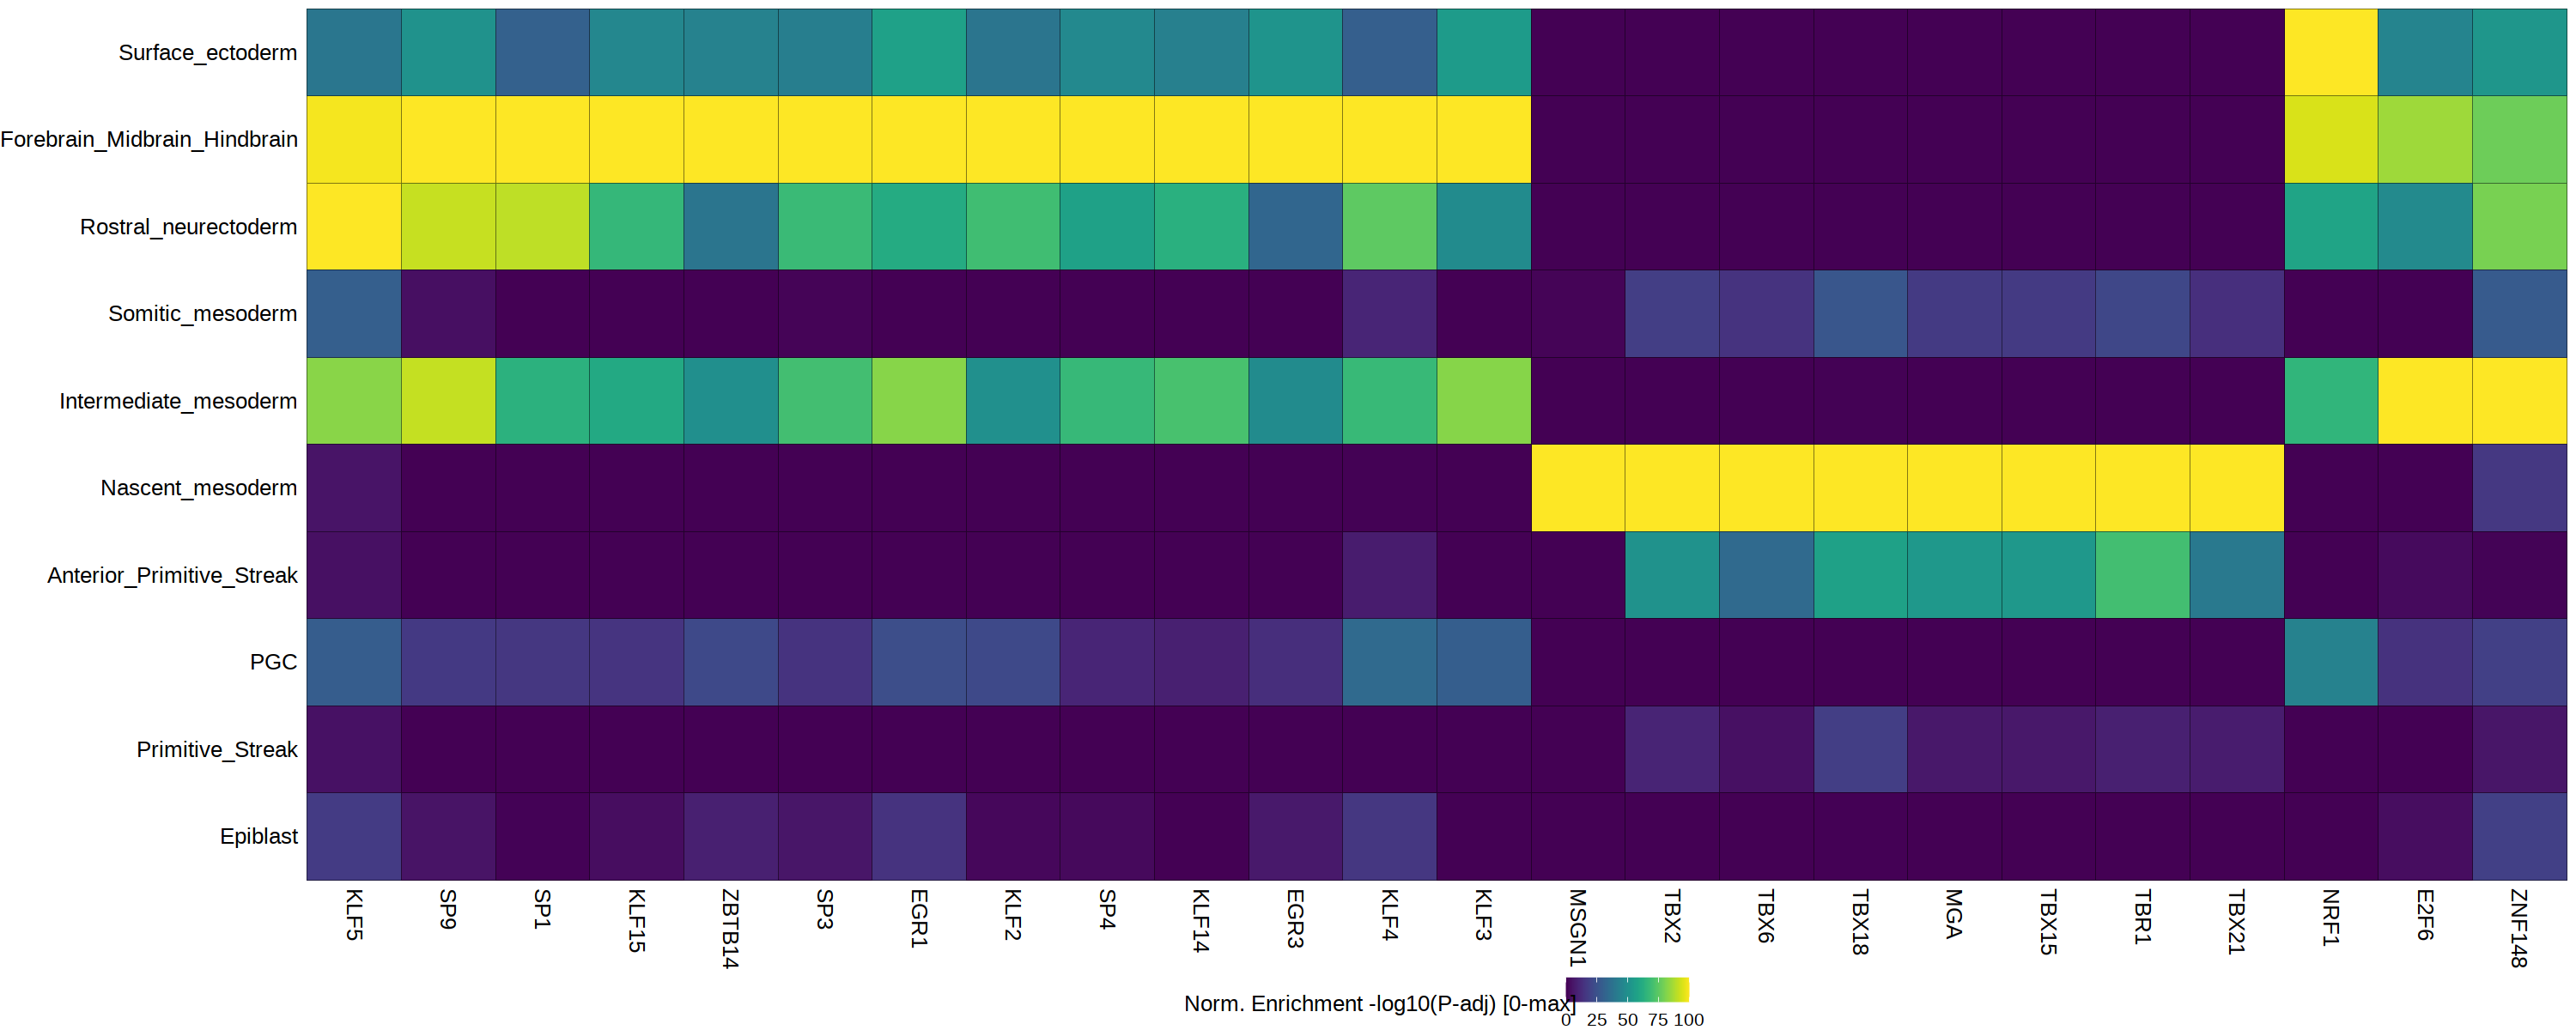

In [196]:
enrichMotifs <- peakAnnoEnrichment(
    seMarker = enrich_full,
    ArchRProj = ArchRProject,
    peakAnnotation = "Motif_JASPAR2020",
    cutOff = "FDR <= 0.1 & Log2FC <= -0.5"
  )

plot_enr_heatmap(enrichMotifs, ntop = 50)

pdf(sprintf('%s/results/atac/archR/differential/motif_down_celltype_jaspar.pdf', io$basedir), width=10, height=6)
     plot_enr_heatmap(enrichMotifs, ntop = 100)
dev.off()

# Motif enrichment for Peaks from Ricards method

In [205]:
DARs = fread(file.path(io$basedir, 'results/atac/archR/differential/DARs.txt.gz'))

In [206]:
enrich_full = list()
for(i in unique(DARs$celltype)){
        tmp1 = merge(data.table(idx=1:nrow(peakset)), DARs[celltype==i], by='idx', all.x=T) %>%
                        .[,c('Log2FC', 'FDR'):=list(ifelse(is.na(logFC), 0, logFC),
                                                    ifelse(is.na(padj_fdr), 1, padj_fdr))]
    tmp2 = markers
    tmp2@assays@data$Log2FC = data.frame('x'=tmp1$Log2FC)
    tmp2@assays@data$FDR = data.frame('x'=tmp1$FDR)
    colnames(tmp2) = i
    enrich_full[[i]] = tmp2
}
enrich_full = do.call('cbind', enrich_full)

In [207]:
plot_enr_heatmap = function(enrichMotifs, ntop=25) {
    heatmapEM <- plotEnrichHeatmap(enrichMotifs, n = ntop, returnMatrix = TRUE)

    enriched.dt = melt(as.data.table(heatmapEM, keep.rownames=T) %>% setnames('rn', 'TF'), id.vars = c("TF")) %>%
        .[order(-value)] 
    keep_tfs = enriched.dt[, head(.SD, ntop),  by=variable]$TF
    enriched.dt = enriched.dt[TF %in% keep_tfs] %>% .[order( -value)] %>% 
        .[,TF:=strsplit(TF, '_') %>% map_chr(1)] %>%
         .[,TF:=factor(TF, levels=unique(TF))] %>%
        .[,variable:=factor(variable, levels=ct_keep)]
    
    p = ggplot(enriched.dt, aes(TF, variable, fill=value)) + 
    geom_tile(col='black') + 
    viridis::scale_fill_viridis(name='Norm. Enrichment -log10(P-adj) [0-max]') + 
    theme_void() + theme(text=element_text(size=15), 
                         axis.text.x=element_text(angle=-90,hjust=0,vjust=0.5), 
                         axis.text.y=element_text(hjust=1),
                        legend.position='bottom')
    return(p)
}

In [208]:
enrich_full

class: SummarizedExperiment 
dim: 66178 28 
metadata(56): MatchInfo Params ... MatchInfo Params
assays(6): Log2FC Mean ... MeanDiff MeanBGD
rownames(66178): 1 2 ... 66177 66178
rowData names(4): seqnames idx start end
colnames(28): Epiblast Rostral_neurectoderm ... Gut Blood_progenitors_1
colData names(0):

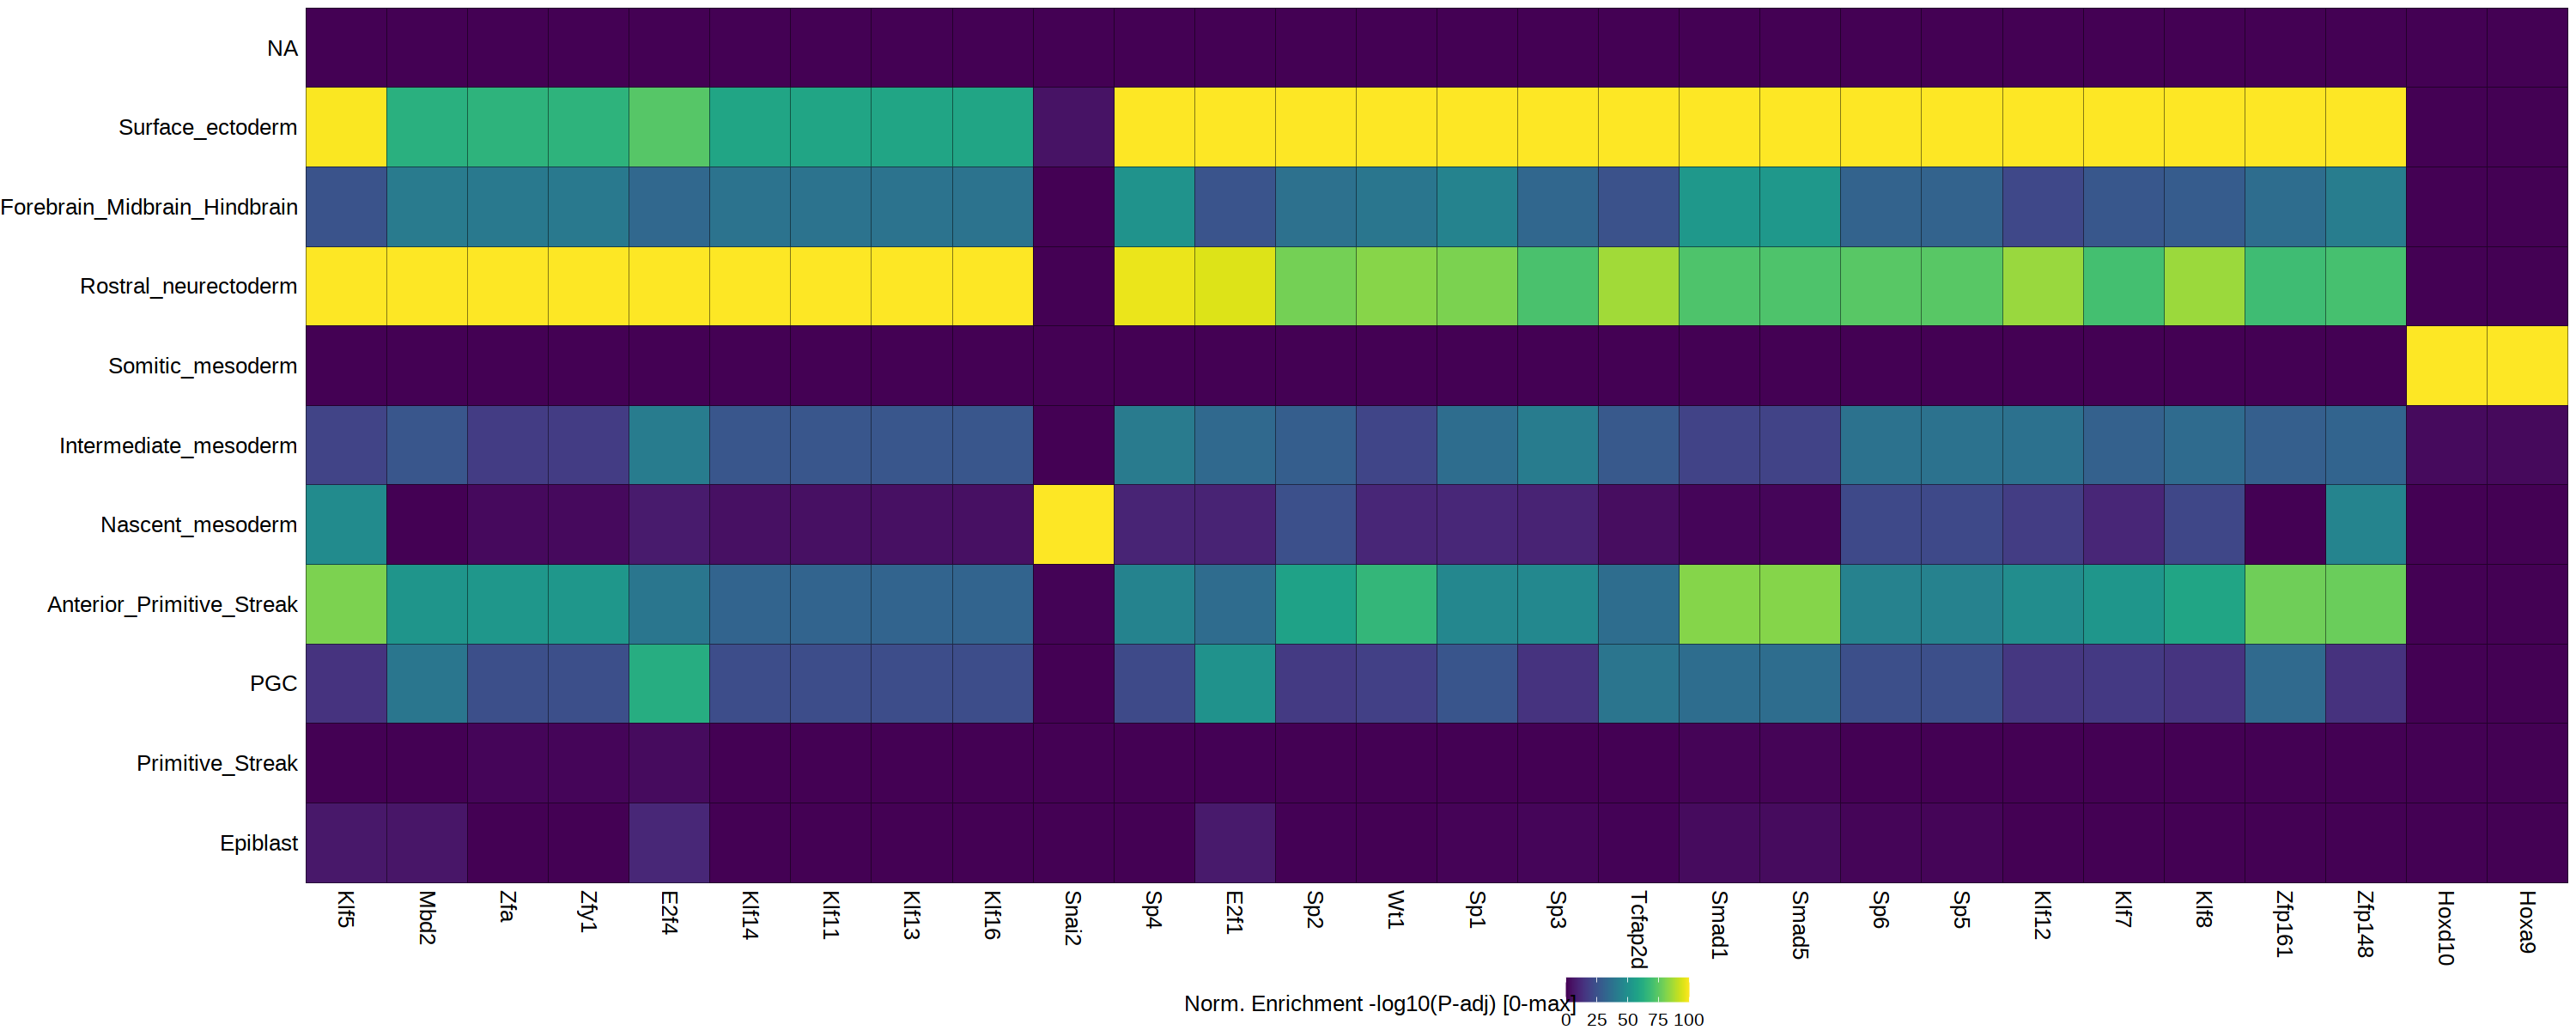

In [209]:
enrichMotifs <- peakAnnoEnrichment(
    seMarker = enrich_full,
    ArchRProj = ArchRProject,
    peakAnnotation = "Motif_cisbp",
    cutOff = "FDR <= 0.1 & Log2FC >= 0.5"
  )
options(repr.plot.width=25, repr.plot.height=10)

plot_enr_heatmap(enrichMotifs, ntop = 100)

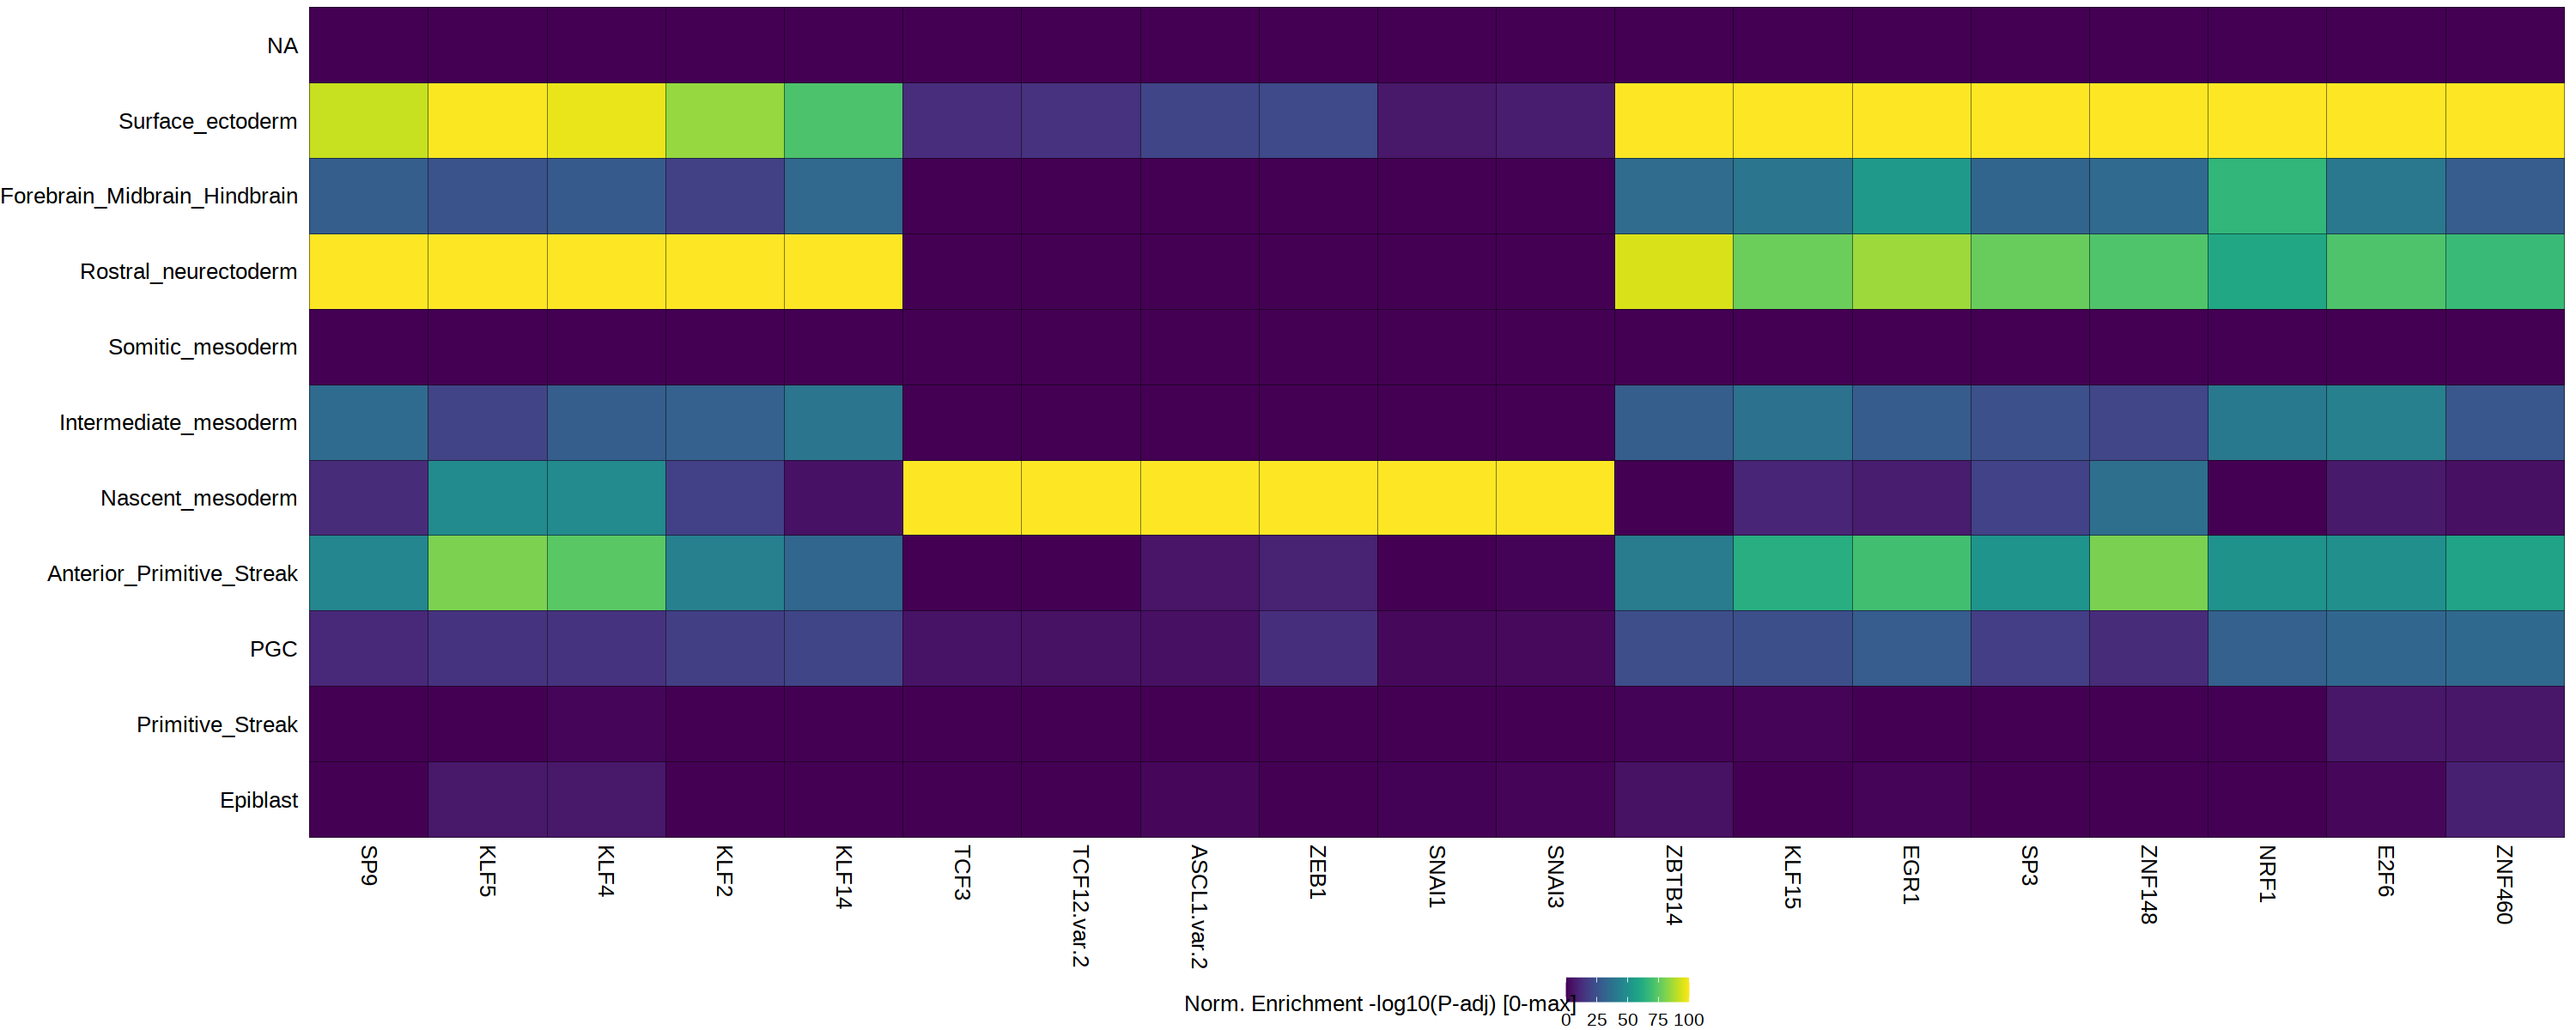

In [210]:
enrichMotifs <- peakAnnoEnrichment(
    seMarker = enrich_full,
    ArchRProj = ArchRProject,
    peakAnnotation = "Motif_JASPAR2020",
    cutOff = "FDR <= 0.1 & Log2FC >= 0.5"
  )
options(repr.plot.width=25, repr.plot.height=10)
plot_enr_heatmap(enrichMotifs, ntop = 80)

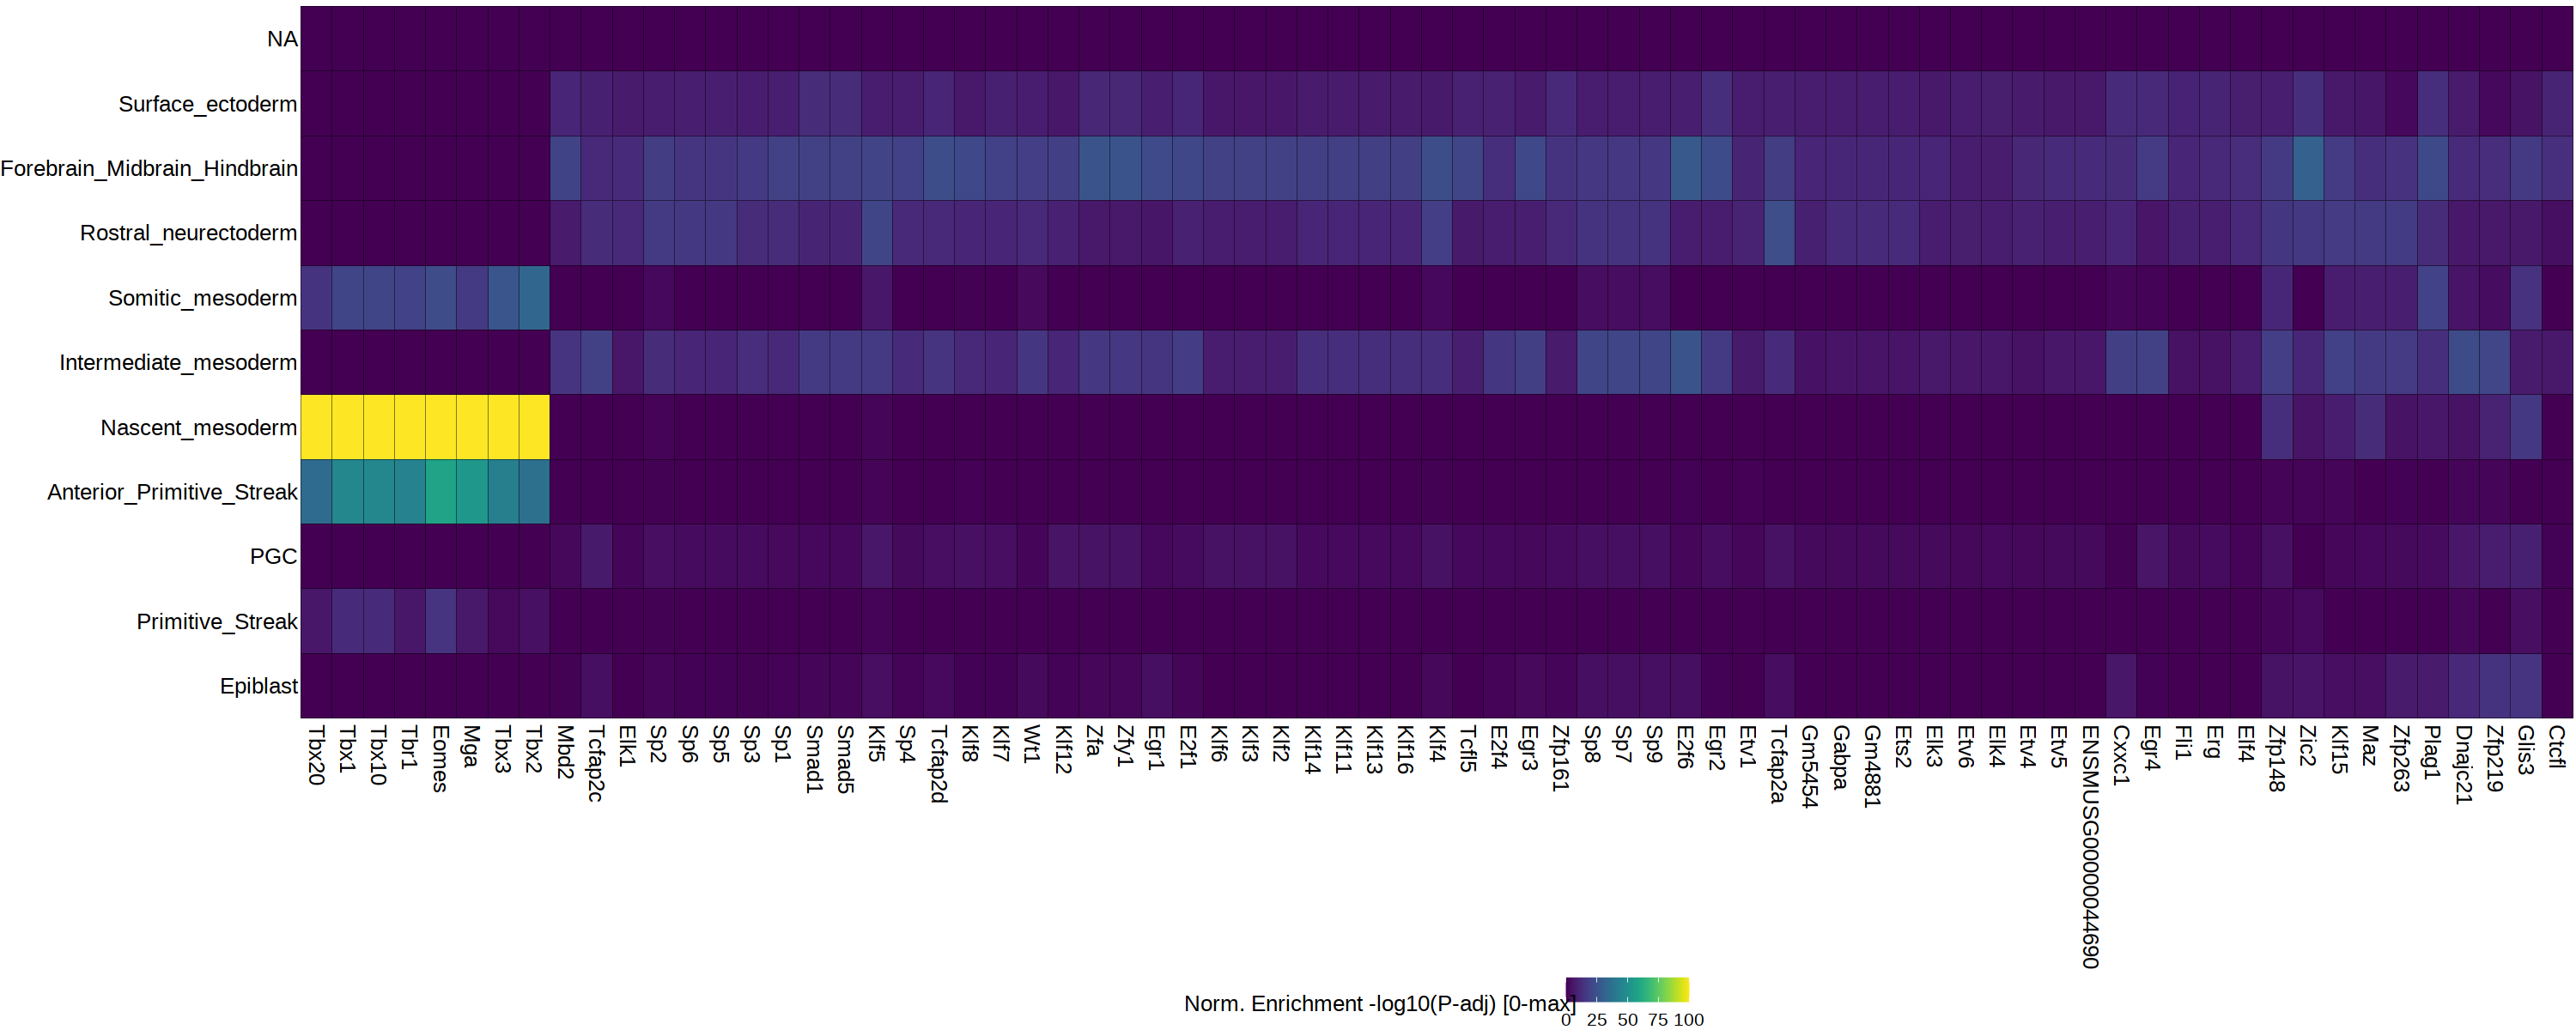

In [211]:
enrichMotifs <- peakAnnoEnrichment(
    seMarker = enrich_full,
    ArchRProj = ArchRProject,
    peakAnnotation = "Motif_cisbp",
    cutOff = "FDR <= 0.1 & Log2FC <= -0.5"
  )
plot_enr_heatmap(enrichMotifs, ntop = 50)

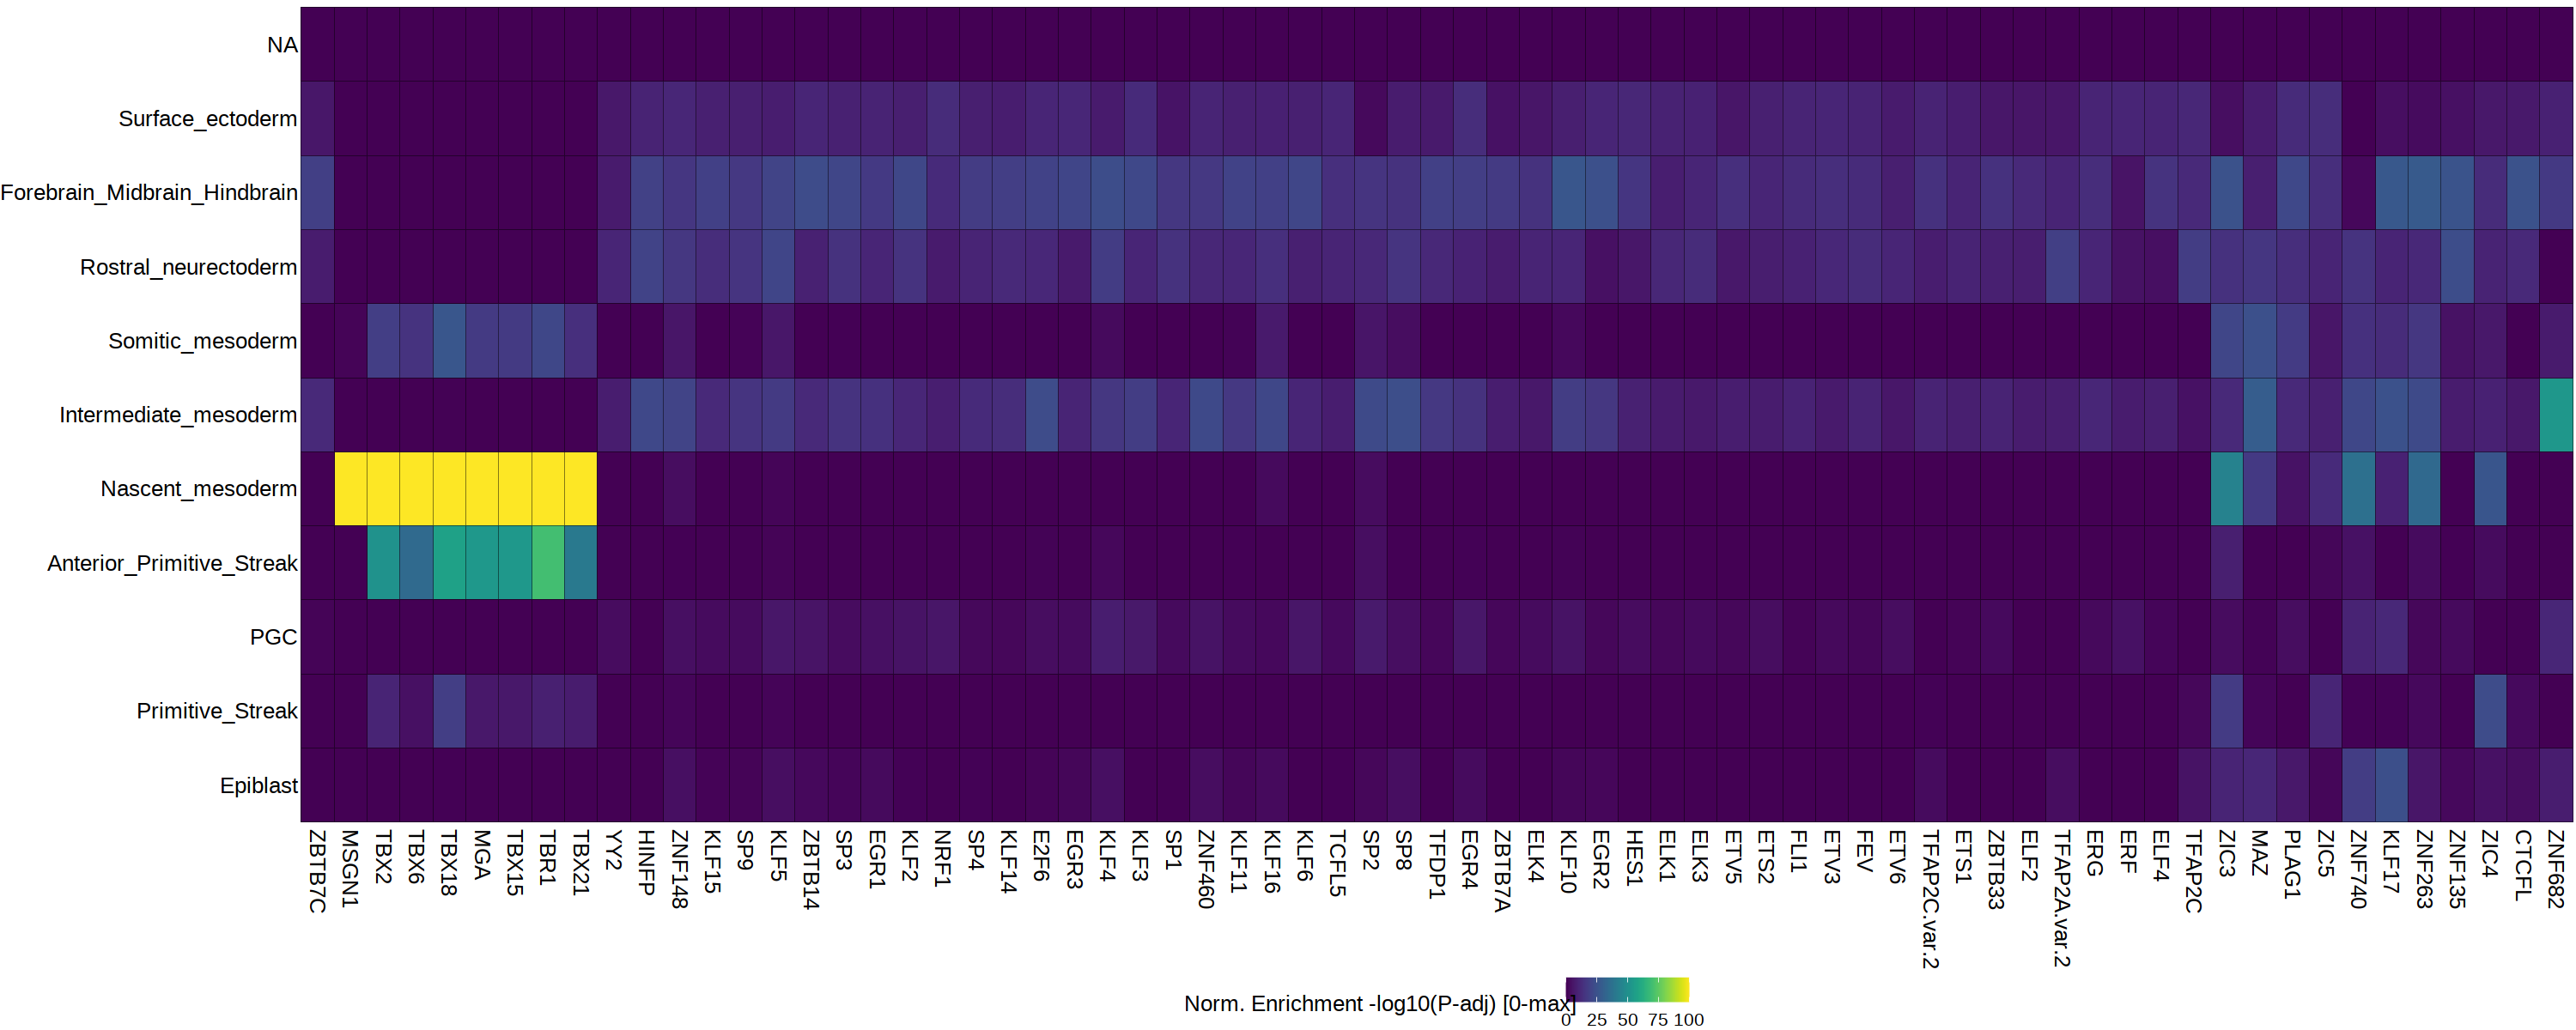

In [212]:
enrichMotifs <- peakAnnoEnrichment(
    seMarker = enrich_full,
    ArchRProj = ArchRProject,
    peakAnnotation = "Motif_JASPAR2020",
    cutOff = "FDR <= 0.1 & Log2FC <= -0.5"
  )

plot_enr_heatmap(enrichMotifs, ntop = 50)